## **CompBioMed Seminars**

**Using Machine Learning for Site of Origin Prediction in Ventricular Arrhythmias from ECGs and Clinical Data**


To run the ECG Data Segmentation section:

Use Python 3.8
Install Torch
Use this command:
pip install git+https://github.com/guillermo-jimenez/sak.git

Once you have processed the Teknon data and built your design matrix, you can create a Python environment with a more modern version.

In [89]:
# ===== PATH CONFIGURATION =====
# Adjust these paths to match your local environment.
# All other cells in this notebook reference these variables instead of hardcoded paths.
import os

# Base data folder (contains the .mat datasets, .pkl files, etc.)
DATA_DIR = r'G:\Meu Drive\Ciència de Dades i Models Computacionals en Biomedicina\cbm_code_data\data'

# Folder containing the pretrained ECG segmentation models (model.1 ... model.5)
MODELS_DIR = r'G:\Meu Drive\Ciència de Dades i Models Computacionals en Biomedicina\cbm_code_data\models'

# Folder containing the Teknon QRS signals (patient_000, patient_001, ...)
TEKNON_QRS_DIR = r'G:\Meu Drive\Ciència de Dades i Models Computacionals en Biomedicina\cbm_code_data\qrs_signals'

# --- Uncomment if running on Google Colab instead of locally ---
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = '/content/drive/MyDrive/Ciència de Dades i Models Computacionals en Biomedicina/cbm_code_data/data'
# MODELS_DIR = '/content/drive/MyDrive/Ciència de Dades i Models Computacionals en Biomedicina/cbm_code_data/models'
# TEKNON_QRS_DIR = '/content/drive/MyDrive/Ciència de Dades i Models Computacionals en Biomedicina/cbm_code_data/qrs_signals'


### 1. Load Datasets

#### 1.1. .mat Datasets (DS-2496, DS-43, DS-334).

In [90]:
import numpy as np
from scipy import signal
from sklearn.preprocessing import normalize
from scipy.io import loadmat
import pickle
import pandas as pd
import matplotlib.pyplot as plt

In [91]:
#pip install git+https://github.com/guillermo-jimenez/sak.git

In [92]:
# DO NOT DELETE -> FOR USE IN VSCODE (sanity check)
print(os.listdir(DATA_DIR))


['full_data_corrected_2024.pkl', 'QRS_CARTO2.mat', 'QRS_Database2.mat', 'QRS_Sims2.mat', 'desktop.ini']


In [93]:
# FOR USE IN GOOGLE COLAB
# See the Colab block in the PATH CONFIGURATION cell above.


In [94]:
def _handle_sublocation(dSim: dict,
                        data_key: str,
                        path: str,
                        X: np.ndarray,
                        y: np.ndarray) -> (np.ndarray, np.ndarray, np.ndarray):
    """
    Handle sublocation classification and remove invalid samples.
    """

    mapping = {
        'LCC': 0, 'RCC': 1, 'COMMISSURE': 2, 'LVOT Subvalvular': 3,
        'LVOT Summit': 4, 'RVOT Septum': 5, 'RFW': 6 #RVOT Free Wall
    }

    #Dataset-specific exclusions
    if path == 'data/QRS_CARTO2.mat':
        invalid_labels = ['RV', []]
    elif path == 'data/QRS_Database2.mat':
        invalid_labels = ['-', 'RVOTOther']
    else:
        invalid_labels = []

    raw_labels = dSim[data_key]["Sublocation"]

    y_sub = []
    valid_indices = []
    unique_labels = []

    for i, label in enumerate(raw_labels[0]):

        try:
            if label[0] in invalid_labels:
                continue

            else:
                if label[0] == 'LCCRCC' or label[0] == 'LCC-RCC':
                    label = 'COMMISSURE'

                elif label[0] == 'Posteroseptal' or label[0] == 'Anteroseptal':
                    label = 'RVOT Septum'

                elif label[0] == "AMC":
                    label = 'LVOT Subvalvular'

                elif label[0] == "Summit":
                    label = 'LVOT Summit'

                else:
                    label = label[0]

                if label in mapping:
                    y_sub.append(mapping[label])
                    valid_indices.append(i)
                    if label not in unique_labels:
                        unique_labels.append(label)
                else:
                    print(f"Warning: unknown sublocation '{label}' at index {i}")

        except:
            print(f"Warning: invalid label format at index {i}: {label}")
            continue


    print(f"Unique sublocation labels found: {unique_labels}")
    #Filter dataset
    X = X[valid_indices]
    y = y[valid_indices]
    y_sub = np.array(y_sub)

    return X, y, y_sub

In [95]:
def _build_binary_target(dSim: dict,
                         data_key: str) -> np.ndarray:
    """
    Build LV (0) vs RV (1) classification target.
    """

    mapping = {"LV": 0, "RV": 1}
    #Handle typo inconsistency in datasets
    key_name = "LeftRight" if "LeftRight" in dSim[data_key].dtype.names else "LeftRigth"

    raw_labels = dSim[data_key][key_name]
    y = np.zeros(len(raw_labels[0]))

    for i, label in enumerate(raw_labels[0]):
        y[i] = mapping[label[0]]

    return y

In [96]:
def _load_mat_dataset(path, sample_size, data_key,
                      lead_names, sublocation):
    """
    Internal function to load .mat ECG datasets.
    """
    #dSim has the data at data_key (e.g., QRS_CARTO), and then for each lead, we have a (1, n_patients) list, where each entry is a (n_samples,) array with the ECG signal for that patient and lead.
    dSim = loadmat(path)

    #Number of patients
    n_patients = dSim[data_key][lead_names[0]].shape[1]
    print(f"Number of patients: {n_patients}")

    #Allocate matrix: (patients × (leads * samples))
    X = np.zeros((n_patients, len(lead_names) * sample_size))

    #Build feature matrix
    for iLead, lead in enumerate(lead_names):
        lead_data = dSim[data_key][lead]

        for i in range(n_patients):
            patient_signal = lead_data[0, i]
            signal_1d = np.asarray(patient_signal).squeeze() #Convert to 1D array

            #Safety check
            if signal_1d.ndim != 1:
                raise ValueError(
                    f"Invalid ECG shape at patient {i}, lead {lead}: {signal_1d.shape}"
                )
            #Resample signal to fixed length
            resampled = signal.resample(signal_1d, sample_size).flatten()

            # Place in correct position
            start = iLead * sample_size
            end = (iLead + 1) * sample_size
            X[i, start:end] = resampled

    #Normalize (important for ML stability)
    X = normalize(X, norm="l1")

    #Build targets
    y = _build_binary_target(dSim, data_key)

    if sublocation:
        X, y, y_sub = _handle_sublocation(dSim, data_key, path, X, y)

    return {
        "data": X,
        "target": y
    }


In [97]:
def load_dataset(path: str,
                 sample_size: int,
                 data_key: str,
                 lead_names: list = None,
                 sublocation: bool = False,
                 shuffle: bool = True,
                 random_state: int = None):
    """
    Load ECG dataset and return (X, y).

    This function:
    1. Loads raw ECG data
    2. Resamples each lead
    3. Flattens all 12 leads into a single vector per patient
    4. Normalizes the data
    5. Builds target labels

    Parameters
    ----------
    path : str
        Path to .mat file
    sample_size : int
        Number of samples per lead after resampling
    data_key : str
        Key inside .mat file (e.g. 'QRS')
    lead_names : list
        ECG leads to use (default: standard 12-lead)
    sublocation : bool
        If True, also compute sublocation labels
    shuffle : bool
        Whether to shuffle dataset
    random_state : int or None
        Seed for reproducibility

    Returns
    -------
    X : np.ndarray
        Shape (n_samples, n_leads * sample_size)
    y : np.ndarray
        Binary labels (LV=0, RV=1)
    """

    if lead_names is None:
        lead_names = ["I","II","III","aVR","aVL","aVF",
                      "V1","V2","V3","V4","V5","V6"]

    print(f"Loading dataset from: {path}")

    # Load and process raw data
    DB_dict = _load_mat_dataset(path, sample_size, data_key,
                                lead_names, sublocation)

    X = DB_dict["data"]
    y = DB_dict["target"]

    # Shuffle if needed
    if shuffle:
        rng = np.random.default_rng(random_state)
        indices = rng.permutation(len(X))
        X = X[indices]
        y = y[indices]

    return X, y

In [98]:
#Load QRS_Carto2.mat
X_Clinic, y_Clinic = load_dataset(os.path.join(DATA_DIR, 'QRS_CARTO2.mat'), sample_size=10, data_key='QRS_CARTO', lead_names=["I","II","III","aVR","aVL","aVF",
                      "V1","V2","V3","V4","V5","V6"], sublocation=True, shuffle=False, random_state=42)


Loading dataset from: G:\Meu Drive\Ciència de Dades i Models Computacionals en Biomedicina\cbm_code_data\data\QRS_CARTO2.mat
Number of patients: 43
Unique sublocation labels found: ['RCC', 'LCC', 'COMMISSURE']


In [99]:
#Load QRS_Database2.mat
X_China, y_China = load_dataset(os.path.join(DATA_DIR, 'QRS_Database2.mat'), sample_size=10, data_key='QRS', lead_names=["I","II","III","aVR","aVL","aVF",
                      "V1","V2","V3","V4","V5","V6"], sublocation=True, shuffle=False, random_state=42)


Loading dataset from: G:\Meu Drive\Ciència de Dades i Models Computacionals en Biomedicina\cbm_code_data\data\QRS_Database2.mat
Number of patients: 333
Unique sublocation labels found: ['RFW', 'RVOT Septum', 'RCC', 'LCC', 'LVOT Summit', 'LVOT Subvalvular', 'COMMISSURE']


In [100]:
#Load QRS_Sims2.mat
X_Sims, y_Sims = load_dataset(os.path.join(DATA_DIR, 'QRS_Sims2.mat'), sample_size=10, data_key='QRS_Sims', lead_names=["I","II","III","aVR","aVL","aVF",
                      "V1","V2","V3","V4","V5","V6"], sublocation=True, shuffle=False, random_state=42)


Loading dataset from: G:\Meu Drive\Ciència de Dades i Models Computacionals en Biomedicina\cbm_code_data\data\QRS_Sims2.mat
Number of patients: 2496
Unique sublocation labels found: ['LCC', 'COMMISSURE', 'RCC', 'LVOT Subvalvular', 'LVOT Summit', 'RVOT Septum', 'RFW']


### 1.2. Load Teknon Dataset

In [101]:
teknon = pickle.load(open(os.path.join(DATA_DIR, 'full_data_corrected_2024.pkl'), 'rb'))

#A. CLINICAL DATA
#Using all the patients in data (first keys), create a .csv with these subkeys:
subkeys = ['Sex', 'HTA', 'Age', 'PVC_transition', 'SOO_chamber', 'Height', 'Weight', 'BMI', 'DM', 'DLP', 'Smoker', 'COPD', 'Sleep_apnea', 'CLINICAL_SCORE', 'SOO', 'OTorigin']

#OTorigin is 1 if "OT" is in the SOO_chamber, otherwise 0. This is not the final RVOT/LVOT origin label, which you will have to build! :)
print(teknon.keys())
clinical_df = pd.DataFrame(columns=subkeys)

#Each clinical subkey is a key of the teknon dictionary
for subkey in subkeys:
    clinical_data = teknon[subkey]
    #This is now a column of the dataframe
    clinical_df[subkey] = clinical_data

display(clinical_df)
print(clinical_df.shape)

dict_keys(['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'Sex', 'HTA', 'Age', 'PVC_transition', 'SOO_chamber', 'Height', 'Weight', 'BMI', 'DM', 'DLP', 'Smoker', 'COPD', 'Sleep_apnea', 'CLINICAL_SCORE', 'SOO', 'OTorigin'])


,Sex,HTA,Age,PVC_transition,SOO_chamber,Height,Weight,BMI,DM,DLP,Smoker,COPD,Sleep_apnea,CLINICAL_SCORE,SOO,OTorigin
0,Female,NaN,61.0,V1,Right ventricle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unión mitroaórtica,0.0
1,Female,No,52.0,V3,RVOT,169.0,68.0,NaN,No,No,No,No,No,1.0,Pared libre anterior,1.0
2,Female,No,69.0,V3,LVOT,156.0,70.0,NaN,No,Yes,No,No,No,1.0,RCC,1.0
3,Female,No,66.0,V4,Right ventricle,176.0,63.0,20.338326,No,No,No,No,No,1.0,M. papilar posteromedial,0.0
4,Female,Yes,46.0,V3,RVOT,160.0,79.0,30.859375,No,No,No,No,No,1.0,RVOT septal,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,Male,Yes,61.0,V1,Right ventricle,188.0,90.0,25.464011,No,No,No,No,No,3.0,LV summit,0.0
177,Male,Yes,52.0,V3,LVOT,182.0,83.0,25.057360,No,No,No,No,No,3.0,Seno de Valsalva dcho.,1.0
178,Male,No,77.0,V6,Right ventricle,NaN,NaN,NaN,No,No,No,No,No,2.0,LV inferobasal,0.0
179,Male,Yes,88.0,V1,Mitral annulus,166.0,90.0,NaN,Yes,Yes,No,No,No,3.0,Anillo mitral anterolateral,0.0


(181, 16)


In [102]:
#### VERY IMPORTANT #####
#### FINAL TEST SET DEFINITION ####

#We define the final test set where the final model configuration will be evaluated. This will be the last 20% of the Teknon data.
test_set = clinical_df.iloc[int(0.8*len(clinical_df)):]

##### ECG Data Segmentation

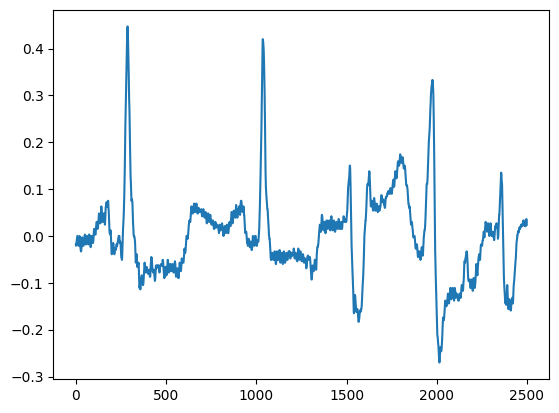

In [103]:
#ECG DATA
#The Teknon dataset has ECG signals with 4 beats, the last of which corresponds to the PVC.
#Using the given segmentation models at models/, you will be able to retrieve all the P, QRS and T waves.

#Of course, you can also use the entire signal as input for your models. In that case, take into account that each lead has different value ranges.
#Moreover, you won't be able to combine your data with the other datasets, since they are segmented in QRS complexes.

#Plot one sample
plt.plot(teknon['I'][0])

In [104]:

#Example with ECG segmentation
import torch
import sak
from functools import partial
import math
import scipy as sp
import skimage
import skimage.util
from typing import List,Tuple
import numpy as np

'''
models_ECG = [
    torch.load(f"/content/drive/MyDrive/Ciència de Dades i Models Computacionals en Biomedicina/cbm_code_data/models/model.{i+1}", weights_only=False) for i in range(5)
]
'''

'\nmodels_ECG = [\n    torch.load(f"/content/drive/MyDrive/Ciència de Dades i Models Computacionals en Biomedicina/cbm_code_data/models/model.{i+1}", weights_only=False) for i in range(5)\n]\n'

In [105]:
models_ECG = [
    torch.load(
        os.path.join(MODELS_DIR, f"model.{i+1}"),
        map_location="cpu",
        weights_only=False
    )
    for i in range(5)
]

# Forçar CPU + modo inferência
for m in models_ECG:
    m.to("cpu")
    m.eval()

print("Models loaded successfully")


Models loaded successfully


In [106]:
from typing import List
def predict_ecg(ecg: np.ndarray, fs: float, model: List[torch.nn.Module],
                window_size: int = 2048, stride: int = 256, threshold_ensemble: float = 0.5,
                thr_dice=0.9, percentile=95, ptg_voting = 0.5, batch_size = 16,
                normalize=True, norm_threshold: float = 1e-6, filter = True) -> np.ndarray:
    """This function is used to delineate an ECG recording of arbitrary size ('ecg' variable, SAMPLES x LEADS)
    and to obtain the fiducials for the P, QRS and T segments as a binary mask of shape 3 x SAMPLES.

    Inputs:
    ecg                <- some array, e.g. shape 198484 x 12
    fs                 <- sampling frequency, e.g. 1000Hz. Will downsample to 250Hz for the AI model to work
    model              <- list of segmentation models for the ensemble
    window_size        <- the "chunk" size that will be processed at a time of the input ecg (e.g., in the example,
                          2048 samples out of the 198484 samples of the ECG)
    stride             <- the "stride" parameter allows for some overlap between the windows of the window_size
    threshold_ensemble <- Percentage of voting for the AI ensemble [0-1]
    thr_dice           <- Threshold for considering each sample as positive according to the Dice score
    percentile         <- Percentile for the amplitude normalization
    ptg_voting         <- Threshold for considering each sample as positive according to the Dice score
    batch_size         <- Number of windows that fit in the batch
    normalize          <- Boolean to indicate whether the ECG has to be normalized. In general, set this to True
                          always, as the ECGs must have the amplitude of a normal sinus rhythm around amplitude of
                          "1" to work, as that was the preprocessing for model training. Only change if a
                          comparable pre-processing is performed
    norm_threshold     <- Threshold for the normalization, to avoid passing baseline wander or noise as signal
    filter             <- Filter the signal with a band-pass filter in [0.5-125] Hz
    """
    # Preprocess signal
    ecg = np.copy(ecg).squeeze()
    if ecg.ndim == 0:
        return np.array([])
    elif ecg.ndim == 1:
        ecg = ecg[:,None]
    elif ecg.ndim == 2:
        if ecg.shape[0] < ecg.shape[1]:
            ecg = ecg.T
    else:
        raise ValueError("2 dims max allowed")

    #Resample to 250Hz if necessary
    if fs != 250:
        ecg_250 = sp.signal.resample(ecg, int(ecg.shape[0]*250/fs), axis=0)
    else:
        ecg_250 = ecg

    # Pad if necessary
    if ecg_250.shape[0] < window_size:
        padding = math.ceil(ecg_250.shape[0]/window_size)*window_size-ecg_250.shape[0]
        ecg_250 = np.pad(ecg_250,((0,padding),(0,0)),mode='edge')
    if (ecg_250.shape[0]-window_size)%stride != 0:
        padding = math.ceil((ecg_250.shape[0]-window_size)/stride)*stride-(ecg_250.shape[0]%window_size)
        ecg_250 = np.pad(ecg_250,((0,padding),(0,0)),mode='edge')

    # Get dimensions
    N,L = ecg_250.shape

    #Normalize amplitudes
    if normalize:
        # Get ecg_250 when it's not flat zero
        norm_signal = ecg_250[np.all(np.abs(np.diff(ecg_250,axis=0,append=0)) >= norm_threshold,axis=1),:]

        # High pass filter normalized ecg_250 to avoid issues with baseline wander
        norm_signal = sp.signal.filtfilt(*sp.signal.butter(2, 0.5/250., 'high'),norm_signal, axis=0)

        # Compute amplitude for those segments
        amplitude = np.array(sak.signal.moving_lambda(
            norm_signal,
            256,
            partial(sak.signal.amplitude,axis=0),
            axis=0
        ))
        amplitude = amplitude[np.all(amplitude > norm_threshold,axis=1),]
        amplitude = np.percentile(amplitude, percentile, axis=0)

        # Apply normalization
        ecg_250 = ecg_250/amplitude[None,:]

    # Filter ecg_250
    if filter:
        ecg_250 = sp.signal.filtfilt(*sp.signal.butter(2,   0.5/250., 'high'),ecg_250,axis=0)
        ecg_250 = sp.signal.filtfilt(*sp.signal.butter(2, 125.0/250.,  'low'),ecg_250,axis=0)
        ecg_250 = sp.signal.lfilter(*sp.signal.iirnotch(50,20.0,250.),ecg_250,axis=0)
        ecg_250 = sp.signal.lfilter(*sp.signal.iirnotch(60,20.0,250.),ecg_250,axis=0)

    # Avoid issues with negative strides due to filtering:
    if np.any(np.array(ecg_250.strides) < 0):
        ecg_250 = ecg_250.copy()

    # Data structure for computing the segmentation
    windowed_signal = skimage.util.view_as_windows(ecg_250,(window_size,1),(stride,1))

    # Flat batch shape
    new_shape = (windowed_signal.shape[0]*windowed_signal.shape[1],*windowed_signal.shape[2:])
    windowed_signal = np.reshape(windowed_signal,new_shape)

    # Exchange channel position
    windowed_signal = np.swapaxes(windowed_signal,1,2)

    # Output structures
    windowed_mask = np.zeros((windowed_signal.shape[0],3,windowed_signal.shape[-1]),dtype=int)

    # Check device for segmentation
    device = "mps" if torch.backends.mps.is_available() else "cpu"

    # Compute segmentation for all leads independently
    with torch.no_grad():
        if isinstance(model,list):
            for m in model:
                m = m.to(device)
                for i in range(0,windowed_signal.shape[0],batch_size):
                    inputs = {"x": torch.tensor(windowed_signal[i:i+batch_size]).float().to(device)}
                    outputs = m(inputs)["sigmoid"].cpu().detach().numpy()
                    windowed_mask[i:i+batch_size] += outputs > thr_dice
            windowed_mask = windowed_mask >= len(model)*threshold_ensemble
        else:
            model = model.to(device)
            for i in range(0,windowed_signal.shape[0],batch_size):
                inputs = {"x": torch.tensor(windowed_signal[i:i+batch_size]).to(device).float()}
                outputs = model(inputs)["sigmoid"].cpu().detach().numpy()
                windowed_mask[i:i+batch_size] = outputs > thr_dice

    # Retrieve mask as 1D
    counter = np.zeros((N), dtype=int)
    segmentation_250 = np.zeros((3,N))

    # Iterate over windows
    for i in range(0,windowed_mask.shape[0],L):
        counter[(i//L)*stride:(i//L)*stride+window_size] += 1
        segmentation_250[:,(i//L)*stride:(i//L)*stride+window_size] += windowed_mask[i:i+L].sum(0)
    segmentation_250 = ((segmentation_250/counter) >= (ecg_250.shape[-1]*ptg_voting))

    # Correct padding
    segmentation_250 = segmentation_250[:,:-padding]

    # Interpolate back to original sampling frequency
    segmentation = sak.signal.interpolate.interp1d(segmentation_250,ecg.shape[0],axis=-1,kind="nearest")

    return segmentation

In [107]:
'''
#Transform the signal from dictionary to numpy array
from sak.signal import StandardHeader
ecg_signals = []
for lead in StandardHeader:
    ecg_signals.append(teknon[lead][0])
ecg_signals = np.asarray(ecg_signals).T
'''
# Transform the signal from dictionary to numpy array
# Transform the signal from dictionary to numpy array
from sak.signal import StandardHeader
import numpy as np

ecg_signals = []

for lead in StandardHeader:
    ecg_signals.append(teknon[lead][0])

# float32 evita crashes/memória excessiva
ecg_signals = np.asarray(ecg_signals).T.astype(np.float32)

print(ecg_signals.shape)
print(ecg_signals.dtype)

(2500, 12)
float32


In [108]:
import sak
import sak.signal
import sak.signal.interpolate

fs = 1000  # Important: 1000 Hz, no 250!
fs_high, fs_low = 0.5, 100.0



In [109]:

'''
# Resample a 250 Hz
ecg_250 = sak.signal.interpolate.interp1d(ecg_signals, round(ecg_signals.shape[0]*250/fs), axis=0).T

# Bandpass filter
ecg_250 = sp.signal.filtfilt(*sp.signal.butter(2, fs_high/250., 'high'), ecg_250, axis=-1)
ecg_250 = sp.signal.filtfilt(*sp.signal.butter(2, fs_low/250., 'low'), ecg_250, axis=-1)
'''
from scipy.signal import resample
import scipy as sp
# Resample a 250 Hz
new_len = round(ecg_signals.shape[0] * 250 / fs)

ecg_250 = resample(
    ecg_signals,
    new_len,
    axis=0
).T

# Garantir float32
ecg_250 = ecg_250.astype(np.float32)

# Bandpass filter
ecg_250 = sp.signal.filtfilt(
    *sp.signal.butter(2, fs_high / 250., 'high'),
    ecg_250,
    axis=-1
)

ecg_250 = sp.signal.filtfilt(
    *sp.signal.butter(2, fs_low / 250., 'low'),
    ecg_250,
    axis=-1
)

print(ecg_250.shape)
print(ecg_250.dtype)

(12, 625)
float64


In [110]:
# Predict segmentation
from scipy.signal import resample
import torch

# Predict segmentation
with torch.no_grad():

    segmentation_250 = predict_ecg(
        ecg_250,
        250.,
        models_ECG,
        normalize=True
    )

print(type(segmentation_250))
print(segmentation_250.shape)

# Check for empty segmentation
if segmentation_250.size == 0:

    print("[WARN] Empty segmentation")

else:

    # Garantir float32
    segmentation_250 = segmentation_250.astype(np.float32)

    # Resample back to original length
    segmentation = resample(
        segmentation_250,
        ecg_signals.shape[0],
        axis=-1
    )

    # Garantir float32
    segmentation = segmentation.astype(np.float32)

    print("segmentation shape:", segmentation.shape)
    print("segmentation dtype:", segmentation.dtype)

<class 'numpy.ndarray'>
(3, 625)
segmentation shape: (3, 2500)
segmentation dtype: float32


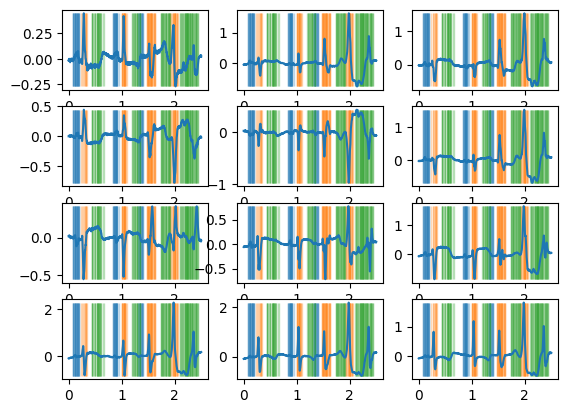

In [111]:
#Plot all the signals
fig, ax = plt.subplots(4,3)
row = 0
col = 0
x = np.linspace(0,2.5,int(fs*2.5))
for i,sig in enumerate(ecg_signals.T):
    ax[row,col].plot(x, sig)
    ax[row,col].fill_between(x, np.min(sig), np.max(sig), where=(segmentation[0,:] == 1), color='C0', alpha = 0.3 )
    ax[row,col].fill_between(x, np.min(sig), np.max(sig), where=(segmentation[1,:] == 1), color='C1', alpha = 0.3 )
    ax[row,col].fill_between(x, np.min(sig), np.max(sig), where=(segmentation[2,:] == 1), color='C2', alpha = 0.3 )
    col += 1
    if col >= 3:
        row += 1
        col = 0

## Standardized the SOOs in the Teknon dataset

In [112]:
import pickle
import json
from collections import Counter, defaultdict

In [113]:
SOO_TO_7CLASS = {

    # RCC
    "RCC":                                          "RCC",
    "Seno de Valsalva dcho.":                       "RCC",
    "Seno valsalva derecho - LVOT":                 "RCC",

    # LCC
    "LCC":                                          "LCC",
    "Left coronary cusp":                           "LCC",
    "Cúspide izquierda":                            "LCC",
    "Seno de Valsalva izdo.":                       "LCC",
    "LVOT Seno de Valsalva izdo.":                  "LCC",
    "LVOT Seno de Valsava izdo.":                   "LCC",   # typo
    "Left coronary cusp, desde el ventriculo izquierdo": "LCC",

    # RCC/LCC Commissure (Intersinus / Intercoronary)
    "Intersenos dcho.-izdo.":                       "RCC/LCC Commissure",
    "Intersenos":                                   "RCC/LCC Commissure",
    "Intersinus":                                   "RCC/LCC Commissure",
    "LVOT intersenos dcho.-izdo.":                  "RCC/LCC Commissure",
    "Intersenos (LV)":                              "RCC/LCC Commissure",

    # Subvalvular LVOT
    "LVOT anterolateral":                           "Subvalvular LVOT",
    "Unión mitroaórtica":                           "Subvalvular LVOT",   # Mitral-aortic junction
    "Anillo mitral inferolateral + Unión M-A":      "Subvalvular LVOT",
    "Septo basal subaótico":                        "Subvalvular LVOT",
    "subvalvular aortico (summit)":                 "Subvalvular LVOT",
    "Anillo mitral anterolateral":                  "Subvalvular LVOT",
    "Anillo mitral anteroseptal":                   "Subvalvular LVOT",
    "Anillo mitral posterior":                      "Subvalvular LVOT",
    "anillo lat":                                   "Subvalvular LVOT",
    "LV inferobasal":                               "Subvalvular LVOT",
    "LV inferolateral basal":                       "Subvalvular LVOT",

    # Summit LVOT
    # (LV summit, epicardial, CS-summit variants)
    "CS distal (summit)":                           "Summit LVOT",
    "LV summit EPI (SC)":                           "Summit LVOT",
    "Crux cordis (SC)":                             "Summit LVOT",
    "Ostium del SC (crux cordis)":                  "Summit LVOT",
    "Ostium de SC":                                 "Summit LVOT",
    "Seno coronario, ramo IV anterior (foco epi)":  "Summit LVOT",


    # Septum RVOT
    "RVOT anteroseptal":                            "Septum RVOT",
    "RVOT anteroseptal subvalvular":                "Septum RVOT",
    "RVOT medioseptal":                             "Septum RVOT",
    "RVOT septal":                                  "Septum RVOT",
    "RVOT septal subvalvular":                      "Septum RVOT",
    "RVOT subvalvular septal":                      "Septum RVOT",
    "RVOT posteroseptal":                           "Septum RVOT",
    "rvot postero septal":                          "Septum RVOT",
    "rvot septo posterior":                         "Septum RVOT",
    "rvot sèeto posterior":                         "Septum RVOT",   # typo
    "rvot septal anterior":                         "Septum RVOT",
    "Septo anterior":                               "Septum RVOT",
    "Septo posterior, immediatamente subvalvular":  "Septum RVOT",
    "septo":                                        "Septum RVOT",
    "Postero Septal Subvalvular":                   "Septum RVOT",
    "Septal posterior y anterior":                  "Septum RVOT",
    "RVOT lateral + septal":                        "Septum RVOT",   # septal component predominant
    "Anillo tricuspídeo anterior":                  "Septum RVOT",
    "Anillo tricuspídeo lateral":                   "Septum RVOT",
    "Anillo tricuspídeo inferior/inferoseptal":     "Septum RVOT",
    "LV inferoseptal medio":                        "Septum RVOT",
    "VI anteroseptal basal":                        "Septum RVOT",
    "VI anteroseptal medio":                        "Septum RVOT",
    "VI inferoseptal basal":                        "Septum RVOT",
    "Inferoseptal basal":                           "Septum RVOT",
    "Septo basal izquierdo":                        "Septum RVOT",
    "Pared anterior-anteroseptal media (IAM)":      "Septum RVOT",
    "LV anteroseptal (foco intramiocárdico)":       "Septum RVOT",
    "LV perihisiana":                               "Septum RVOT",
    "Infundibulo":                                  "Septum RVOT",
    "Infudibulo":                                   "Septum RVOT",
    "Infundíbulo":                                  "Septum RVOT",

    # Free Wall RVOT (RFW)
    "RVOT":                                         "Free Wall RVOT",
    "RVOT anterior":                                "Free Wall RVOT",
    "RVOT anterolateral":                           "Free Wall RVOT",
    "RVOT lateral":                                 "Free Wall RVOT",
    "RVOT posterolateral":                          "Free Wall RVOT",
    "RVOT posterior":                               "Free Wall RVOT",
    "Pared libre anterior":                         "Free Wall RVOT",
    "pared libre anterior":                         "Free Wall RVOT",
    "Pared libre anterolateral":                    "Free Wall RVOT",
    "rvot - pared libre":                           "Free Wall RVOT",
    "rvot pared libre":                             "Free Wall RVOT",
    "Banda moderadora":                             "Free Wall RVOT",
    "M. papilar anterolateral":                     "Free Wall RVOT",
    "M. papilar posteromedial":                     "Free Wall RVOT",
    "Musculo papilar infero-medial":                "Free Wall RVOT",
    "Papilar anterolateral":                        "Free Wall RVOT",
    "Papilar inferior":                             "Free Wall RVOT",
    "Papilar inferolateral":                        "Free Wall RVOT",
    "papilar lateral":                              "Free Wall RVOT",
}

In [114]:
# Cases depending on SOO_chamber (ambiguous)
AMBIGUOUS = {
    ("LV summit", "LVOT"):           "Summit LVOT",
    ("LV summit", "Coronary sinus"): "Summit LVOT",
    ("LV summit", "Right ventricle"):"Summit LVOT",
    ("LV summit", "Left ventricle"): "Summit LVOT",
    ("Summit",    "LVOT"):           "Summit LVOT",
    ("Summit",    "Coronary sinus"): "Summit LVOT",
    ("Summit",    "Right ventricle"):"Summit LVOT",
    ("Summit",    "Left ventricle"): "Summit LVOT",
}

In [115]:
# Descriptive sub-labels for "Other" records
OTHER_SUBLABEL = {
    # Fascicular
    "Fascicular anterior":              "Other: LV papillary (anterior)",
    "Fascicular posterior":             "Other: LV papillary (posterior)",
    "Fascículo anterior":               "Other: LV papillary (anterior)",
    "fasciculo anterior LV":            "Other: LV papillary (anterior)",
    # LV body
    "LV anteroseptal (foco intramiocárdico)": "Other: LV body (anteroseptal intramyocardial)",
    "LV inferobasal":                   "Other: LV body (inferobasal)",
    "LV inferolateral basal":           "Other: LV body (inferolateral basal)",
    "LV perihisiana":                   "Other: LV body (para-Hisian)",
}

In [116]:
def classify_7(soo_raw, chamber_raw):
    s = str(soo_raw).strip()
    c = str(chamber_raw).strip()

    if s == "nan":
        return "Unknown", "NaN/missing"

    # Disambiguation first
    if (s, c) in AMBIGUOUS:
        cls = AMBIGUOUS[(s, c)]
        return cls, cls

    # Direct mapping
    if s in SOO_TO_7CLASS:
        cls = SOO_TO_7CLASS[s]
        return cls, cls

    # Other with sub-label
    if s in OTHER_SUBLABEL:
        return "Other", OTHER_SUBLABEL[s]

    return "Other", f"Other: {s} [{c}]"

In [119]:
with open('../data/full_data_corrected_2024.pkl', 'rb') as f:
    data = pickle.load(f)

soo_raw     = data['SOO']
chamber_raw = data['SOO_chamber']
n = len(soo_raw)

soo_7class   = []
soo_7detail  = []

for s, c in zip(soo_raw, chamber_raw):
    cls, detail = classify_7(s, c)
    soo_7class.append(cls)
    soo_7detail.append(detail)

In [120]:
CLASS_ORDER = ["RCC", "LCC", "RCC/LCC Commissure",
               "Subvalvular LVOT", "Summit LVOT",
               "Septum RVOT", "Free Wall RVOT",
               "Other", "Unknown"]

cnt = Counter(soo_7class)

print("=" * 70)
print("7-CLASS STANDARDIZATION — Teknon Dataset DS-114")
print("=" * 70)
print(f"\nTotal records : {n}")
print()
print(f"{'Class':<25} {'N':>5}  {'%':>6}")
print("-" * 40)
for cls in CLASS_ORDER:
    v = cnt.get(cls, 0)
    pct = 100 * v / n
    bar = "█" * int(pct / 2)
    print(f"  {cls:<23} {v:>5}  {pct:>5.1f}%  {bar}")

print()
print("'Other' Details")
other_detail = Counter(d for d, c in zip(soo_7detail, soo_7class) if c == "Other")
for k, v in sorted(other_detail.items(), key=lambda x: -x[1]):
    print(f"  {v:3d}  {k}")

print()
print("Verification: SOO_raw → SOO_7class (RVOT sample) ")
reverse = defaultdict(set)
for s, cls in zip(soo_raw, soo_7class):
    reverse[cls].add(str(s))
for cls in ["Septum RVOT", "Free Wall RVOT", "RCC", "LCC", "RCC/LCC Commissure",
            "Subvalvular LVOT", "Summit LVOT"]:
    print(f"\n  [{cls}]")
    for v in sorted(reverse[cls]):
        print(f"    · {v}")

7-CLASS STANDARDIZATION — Teknon Dataset DS-114

Total records : 181

Class                         N       %
----------------------------------------
  RCC                         9    5.0%  ██
  LCC                        11    6.1%  ███
  RCC/LCC Commissure         13    7.2%  ███
  Subvalvular LVOT           18    9.9%  ████
  Summit LVOT                21   11.6%  █████
  Septum RVOT                56   30.9%  ███████████████
  Free Wall RVOT             46   25.4%  ████████████
  Other                       6    3.3%  █
  Unknown                     1    0.6%  

'Other' Details
    3  Other: LV papillary (anterior)
    2  Other: Anillo tricuspídeo septal [Tricuspid annulus]
    1  Other: LV papillary (posterior)

Verification: SOO_raw → SOO_7class (RVOT sample) 

  [Septum RVOT]
    · Anillo tricuspídeo anterior
    · Anillo tricuspídeo inferior/inferoseptal
    · Anillo tricuspídeo lateral
    · Inferoseptal basal
    · Infudibulo
    · Infundibulo
    · Infundíbulo
    · LV ant

In [121]:
# save changes

data['SOO_7class']  = soo_7class
data['SOO_7detail'] = soo_7detail

# MODIFIED: Saving to local directory
with open('full_data_7class.pkl', 'wb') as f:
    pickle.dump(data, f)

# Mapping table
table = []
for i, (raw, ch, cls, det) in enumerate(zip(soo_raw, chamber_raw, soo_7class, soo_7detail)):
    table.append({
        "idx": i,
        "SOO_raw": str(raw),
        "SOO_chamber_raw": str(ch),
        "SOO_7class": cls,
        "SOO_7detail": det,
    })

with open('soo_7class_mapping.json', 'w', encoding='utf-8') as f:
    json.dump(table, f, ensure_ascii=False, indent=2)

print("\n\n✓ Dataset saved:  full_data_7class.pkl")
print("✓ Mapping saved:  soo_7class_mapping.json")



✓ Dataset saved:  full_data_7class.pkl
✓ Mapping saved:  soo_7class_mapping.json


In [122]:
import pandas as pd

# Recreate clinical_df using the 'data' variable available in the kernel
subkeys = ['Sex', 'HTA', 'Age', 'PVC_transition', 'SOO_chamber', 'Height', 'Weight', 'BMI', 'DM', 'DLP', 'Smoker', 'COPD', 'Sleep_apnea', 'CLINICAL_SCORE', 'SOO', 'OTorigin']
clinical_df = pd.DataFrame(columns=subkeys)
for subkey in subkeys:
    clinical_data = data[subkey]
    clinical_df[subkey] = clinical_data

clinical_df['SOO_7class'] = data['SOO_7class']
print(clinical_df['SOO_7class'].value_counts())

SOO_7class
Septum RVOT           56
Free Wall RVOT        46
Summit LVOT           21
Subvalvular LVOT      18
RCC/LCC Commissure    13
LCC                   11
RCC                    9
Other                  6
Unknown                1
Name: count, dtype: int64


### Grouping of 7 zones into 3 classes

SOO_7class -> SOO_3class

In [123]:
MAP_7_TO_3 = {
    # Classe 0: RVOT
    "Septum RVOT": 0,
    "Free Wall RVOT": 0,

    # Classe 1: Cúspides / Comissura
    "RCC": 1,
    "LCC": 1,
    "RCC/LCC Commissure": 1,

    # Classe 2: LVOT
    "Summit LVOT": 2,
    "Subvalvular LVOT": 2,
}

MAP_3_NAMES = {
    0: "RVOT Septum / RVOT Free Wall",
    1: "RCC / LCC / Commissure",
    2: "LVOT Summit / LVOT Subvalvular",
}

# Criar nova etiqueta de 3 classes mapeando a de 7 classes
clinical_df["SOO_3class"] = clinical_df["SOO_7class"].map(MAP_7_TO_3)

# Remover pacientes "Other" ou "Unknown" (que ficam como NaN) pois não entram na Task 2
clinical_df_task2 = clinical_df.dropna(subset=["SOO_3class"]).copy()

clinical_df_task2["SOO_3class"] = clinical_df_task2["SOO_3class"].astype(int)
clinical_df_task2["SOO_3class_name"] = clinical_df_task2["SOO_3class"].map(MAP_3_NAMES)

print("Distribuição Task 2:")
print(clinical_df_task2["SOO_3class"].value_counts().sort_index())

print("\nDistribuição com nomes:")
print(clinical_df_task2["SOO_3class_name"].value_counts())

Distribuição Task 2:
SOO_3class
0    102
1     33
2     39
Name: count, dtype: int64

Distribuição com nomes:
SOO_3class_name
RVOT Septum / RVOT Free Wall      102
LVOT Summit / LVOT Subvalvular     39
RCC / LCC / Commissure             33
Name: count, dtype: int64


## Training, Validation and Test split

In [124]:
# Combine Unknown with Other
clinical_df['SOO_7class'] = clinical_df['SOO_7class'].replace('Unknown', 'Other')
print(clinical_df['SOO_7class'].value_counts())

SOO_7class
Septum RVOT           56
Free Wall RVOT        46
Summit LVOT           21
Subvalvular LVOT      18
RCC/LCC Commissure    13
LCC                   11
RCC                    9
Other                  7
Name: count, dtype: int64


In [125]:
from sklearn.model_selection import train_test_split

train_val_df = clinical_df.iloc[:int(0.8 * len(clinical_df))].copy()

#### VERY IMPORTANT #####
#### FINAL TEST SET DEFINITION ####
#We define the final test set where the final model configuration will be evaluated. This will be the last 20% of the Teknon data.
train_val_df = clinical_df_task2.iloc[:int(0.8 * len(clinical_df_task2))].copy()
test_set = clinical_df_task2.iloc[int(0.8 * len(clinical_df_task2)):]

feature_cols = ['Sex', 'HTA', 'Age', 'Height', 'Weight', 'BMI',
                'DM', 'DLP', 'Smoker', 'PVC_transition', 'CLINICAL_SCORE']
target_col   = 'SOO_3class'

X_train_val = train_val_df[feature_cols]
y_train_val = train_val_df[target_col]

X_test = test_set[feature_cols]
y_test = test_set[target_col]

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.2,
    stratify=y_train_val,
    random_state=42
)

print(f"Treino:    {X_train.shape}")
print(f"Validação: {X_val.shape}")
print(f"Teste:     {X_test.shape}")

Treino:    (111, 11)
Validação: (28, 11)
Teste:     (35, 11)


## EDA

In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Map specific keys clinical names
mapping = {
    'Age': 'Age',
    'Sex': 'Sex',
    'BMI': 'BMI',
    'HTA': 'Hypertension',
    'DM': 'Diabetes',
    'DLP': 'Dyslipidemia',
    'Smoker': 'Smoking',
    'Weight': 'Weight',
    'Height': 'Height'
}

In [127]:
# DataFrame using only existing keys
df_clinical = pd.DataFrame({eng: data[original] for original, eng in mapping.items() if original in data})
df_clinical['SOO_7class'] = data['SOO_7class']

print("--- Clinical DataFrame Summary ---")
print(df_clinical.info())
print(df_clinical.head())

--- Clinical DataFrame Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           178 non-null    float64
 1   Sex           179 non-null    object 
 2   BMI           99 non-null     float64
 3   Hypertension  175 non-null    object 
 4   Diabetes      174 non-null    object 
 5   Dyslipidemia  175 non-null    object 
 6   Smoking       173 non-null    object 
 7   Weight        153 non-null    float64
 8   Height        153 non-null    float64
 9   SOO_7class    181 non-null    object 
dtypes: float64(4), object(6)
memory usage: 14.3+ KB
None
    Age     Sex        BMI Hypertension Diabetes Dyslipidemia Smoking  Weight  \
0  61.0  Female        NaN          NaN      NaN          NaN     NaN     NaN   
1  52.0  Female        NaN           No       No           No      No    68.0   
2  69.0  Female        NaN           No    

C:\Users\vitor\AppData\Local\Temp\ipykernel_18224\1971160565.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clinical, x='SOO_7class', y='Age', palette='viridis')


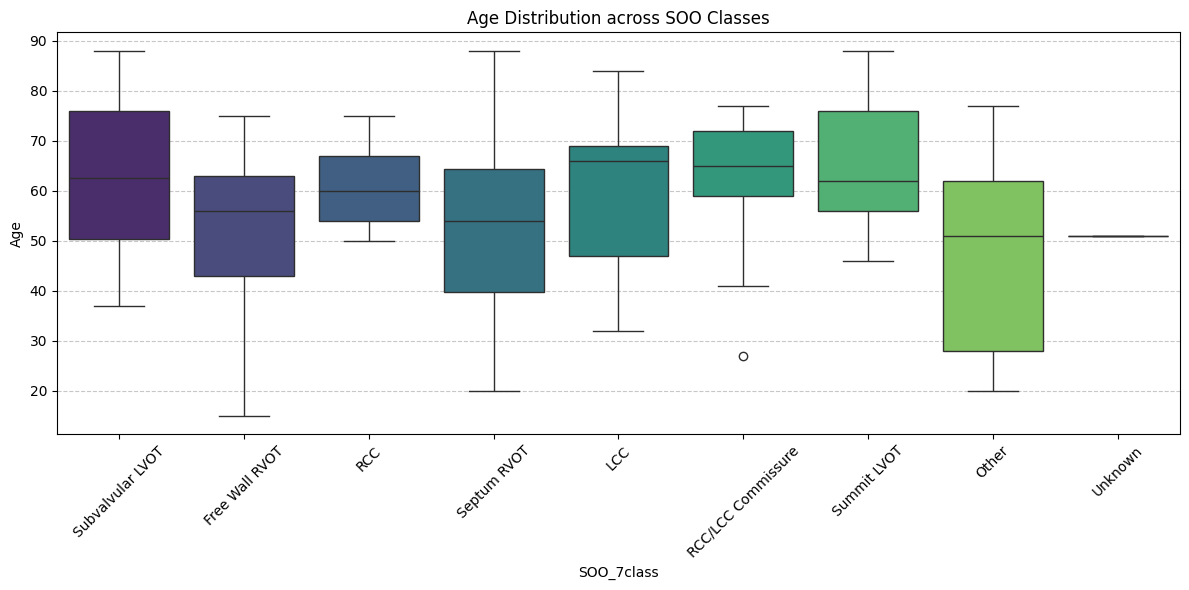

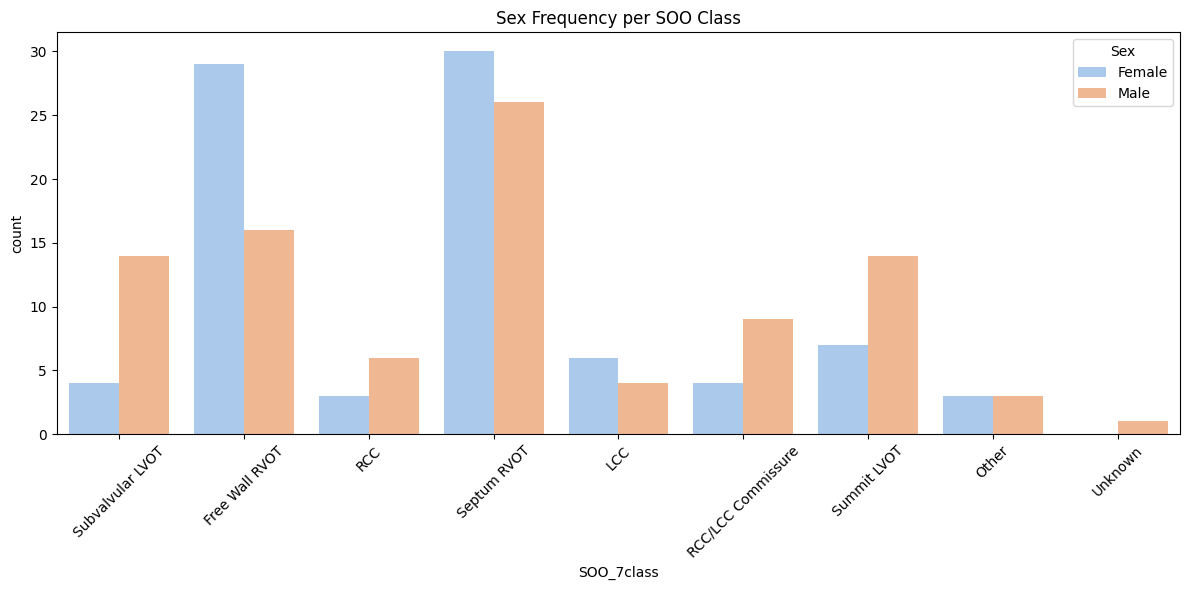

In [128]:
# Visualization

#Age Distribution by SOO Class
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clinical, x='SOO_7class', y='Age', palette='viridis')
plt.title('Age Distribution across SOO Classes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Sex Distribution by SOO Class
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clinical, x='SOO_7class', hue='Sex', palette='pastel')
plt.title('Sex Frequency per SOO Class')
plt.xticks(rotation=45)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

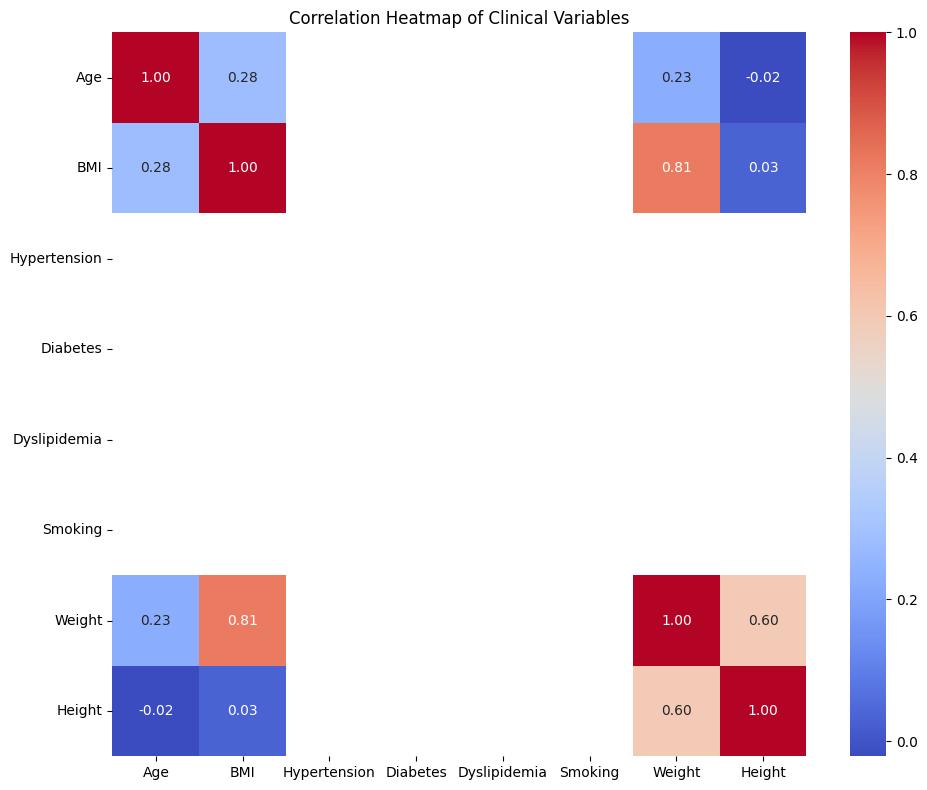

In [129]:
# Correlation Heatmap (Binary/Numeric variables)
# Converting binary categories to numeric for the correlation matrix
df_corr = df_clinical.copy()
binary_cols = ['Hypertension', 'Diabetes', 'Dyslipidemia', 'Smoking']
for col in binary_cols:
    if col in df_corr.columns:
        # Fill NaNs with 0 and convert to int
        df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce').fillna(0).astype(int)

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Clinical Variables')
plt.tight_layout()
plt.show()

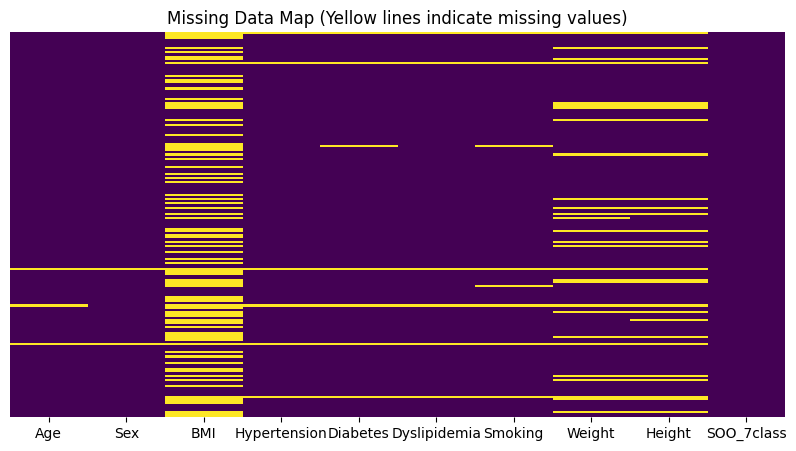


Missing values count:
Age              3
Sex              2
BMI             82
Hypertension     6
Diabetes         7
Dyslipidemia     6
Smoking          8
Weight          28
Height          28
SOO_7class       0
dtype: int64


In [130]:
# Missing Values
plt.figure(figsize=(10, 5))
sns.heatmap(df_clinical.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Map (Yellow lines indicate missing values)')
plt.show()

print("\nMissing values count:")
print(df_clinical.isnull().sum())

C:\Users\vitor\AppData\Local\Temp\ipykernel_18224\2430874358.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clinical, x='SOO_7class', y='BMI', palette='muted', inner="quartile")


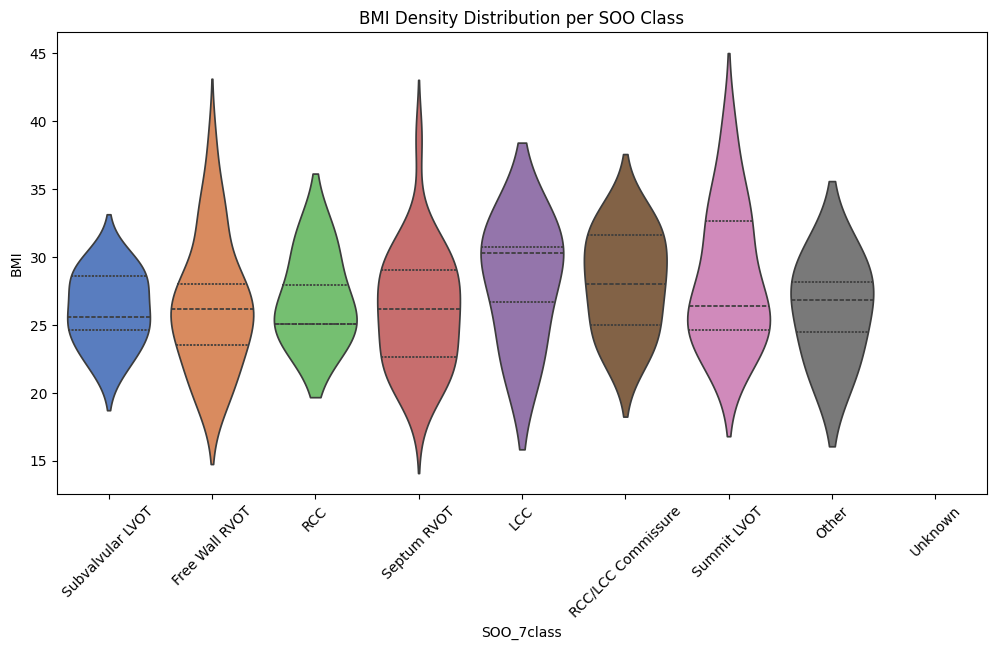

In [131]:
#distribution

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_clinical, x='SOO_7class', y='BMI', palette='muted', inner="quartile")
plt.title('BMI Density Distribution per SOO Class')
plt.xticks(rotation=45)
plt.show()

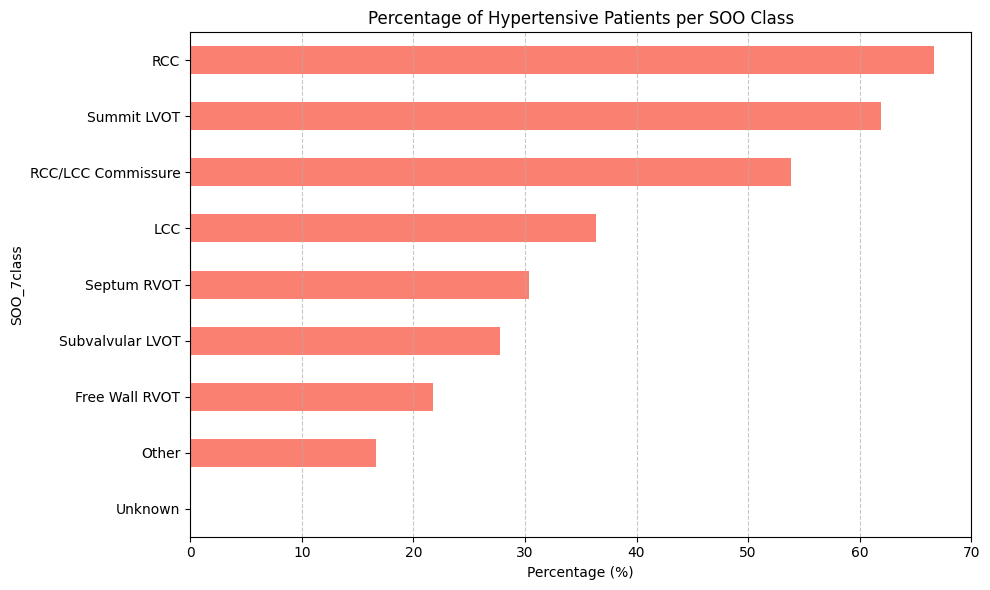

In [132]:
# risk composition -> Proportion of Hypertension per class

# Function to clean binary columns properly
def clean_binary(series):
    # Convert to string, lowercase, and strip spaces
    s = series.astype(str).str.lower().str.strip()
    # Map common representations to 1, everything else to 0
    return s.map({'1': 1, '1.0': 1, 'true': 1, 'yes': 1, 'si': 1}).fillna(0).astype(int)

# Apply to your columns
binary_cols = ['Hypertension', 'Diabetes', 'Dyslipidemia', 'Smoking']
for col in binary_cols:
    if col in df_clinical.columns:
        df_clinical[col] = clean_binary(df_clinical[col])

# Calculate and Plot
prop_hta = df_clinical.groupby('SOO_7class')['Hypertension'].mean() * 100

if prop_hta.sum() == 0:
    print("WARNING: All values are still zero. Check: df_clinical['Hypertension'].value_counts()")
else:
    plt.figure(figsize=(10, 6))
    prop_hta.sort_values().plot(kind='barh', color='salmon')
    plt.title('Percentage of Hypertensive Patients per SOO Class')
    plt.xlabel('Percentage (%)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Class balance

C:\Users\vitor\AppData\Local\Temp\ipykernel_18224\1550690846.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='magma')


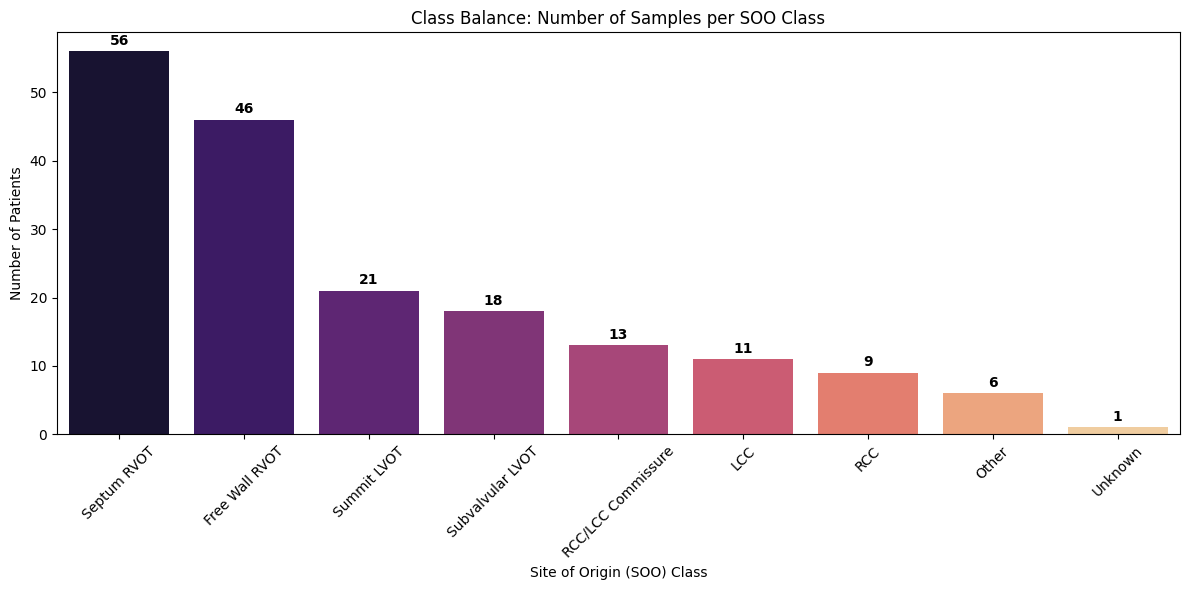

--- Class Distribution (%) ---
SOO_7class
Septum RVOT           30.939227
Free Wall RVOT        25.414365
Summit LVOT           11.602210
Subvalvular LVOT       9.944751
RCC/LCC Commissure     7.182320
LCC                    6.077348
RCC                    4.972376
Other                  3.314917
Unknown                0.552486
Name: proportion, dtype: float64


In [133]:
#Calculate class counts
class_counts = df_clinical['SOO_7class'].value_counts()

#Plotting the Class Balance
plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='magma')

plt.title('Class Balance: Number of Samples per SOO Class')
plt.xlabel('Site of Origin (SOO) Class')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)

for i, count in enumerate(class_counts.values):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Percentage distribution
print("--- Class Distribution (%) ---")
print(df_clinical['SOO_7class'].value_counts(normalize=True) * 100)

C:\Users\vitor\AppData\Local\Temp\ipykernel_18224\1579027452.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette="magma")


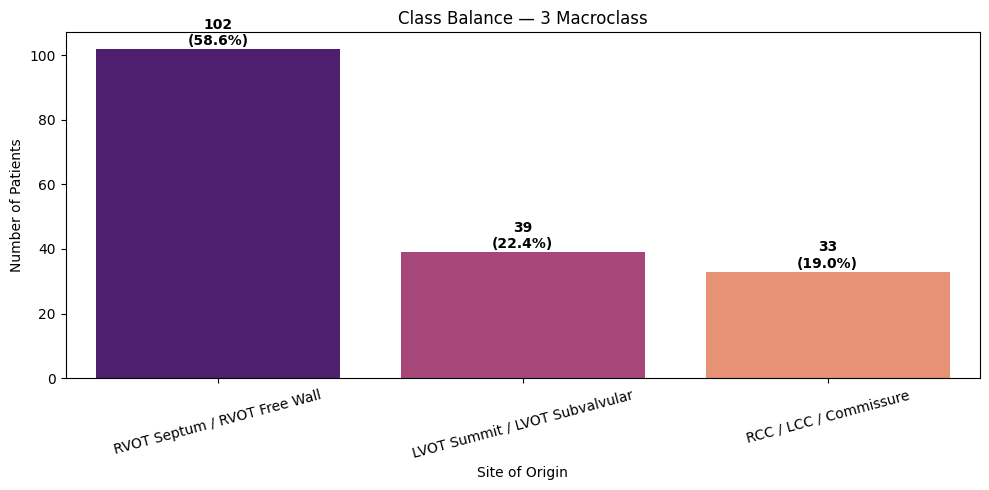

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

class_counts = clinical_df_task2["SOO_3class_name"].value_counts()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette="magma")

plt.title("Class Balance — 3 Macroclass")
plt.xlabel("Site of Origin")
plt.ylabel("Number of Patients")
plt.xticks(rotation=15)

for i, count in enumerate(class_counts.values):
    ax.text(i, count + 0.3, f"{count}\n({100*count/len(clinical_df_task2):.1f}%)",
            ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

## QRS extraction from the Teknon DATASET


In [135]:
import os
import numpy as np
from scipy import ndimage

In [136]:
def segment_all_records(teknon, models_ECG, fs=1000):
    all_segmentations = {}

    for idx in range(len(teknon["I"])):
        ecg_signals = []
        for lead in StandardHeader:
            ecg_signals.append(np.asarray(teknon[lead][idx]).squeeze())
        ecg_signals = np.asarray(ecg_signals).T

        ecg_250 = sak.signal.interpolate.interp1d(
            ecg_signals,
            round(ecg_signals.shape[0] * 250 / fs),
            axis=0
        ).T

        ecg_250 = sp.signal.filtfilt(*sp.signal.butter(2, 0.5/250., 'high'), ecg_250, axis=-1)
        ecg_250 = sp.signal.filtfilt(*sp.signal.butter(2, 100.0/250., 'low'), ecg_250, axis=-1)

        segmentation_250 = predict_ecg(ecg_250, 250., models_ECG, normalize=True, filter=False)

        if segmentation_250.size == 0:
            print(f"[WARN] Empty segmentation at record {idx}")
            all_segmentations[idx] = np.array([])
            continue

        segmentation = sak.signal.interpolate.interp1d(
            segmentation_250,
            ecg_signals.shape[0],
            axis=-1,
            kind="nearest"
        )

        all_segmentations[idx] = segmentation
        print(f"[OK] Record {idx} segmented")

    return all_segmentations

In [137]:
# Executa la teva funció
all_segmentations = segment_all_records(teknon, models_ECG)

qrs_index = []

for patient_id, segmentation in all_segmentations.items():
    print(f"Processant pacient {patient_id}...")

    # Carrega ECG d'aquest pacient (12 derivacions)
    leads = ['I','II','III','AVR','AVL','AVF','V1','V2','V3','V4','V5','V6']
    ecg_signals = np.stack([teknon[lead][patient_id] for lead in leads]).T

    # Aplica màscara QRS → SENYAL RESULTANT
    qrs_mask = segmentation[1]
    qrs_signals = ecg_signals * qrs_mask[:, np.newaxis]

    # CARPETA PER PACIENT
    patient_dir = f"qrs_signals/patient_{patient_id:03d}"
    os.makedirs(patient_dir, exist_ok=True)

    # Guarda senyal complet del pacient
    np.save(f"{patient_dir}/full.npy", qrs_signals)

    # Detecta QRS individuals
    qrs_bool = qrs_mask > 0.5
    labels, n_qrs = ndimage.label(qrs_bool)

    for qrs_id in range(n_qrs):
        idx = np.where(labels == qrs_id + 1)[0]
        if len(idx) > 0:
            start, end = idx[0], idx[-1] + 1
            qrs_seg = qrs_signals[start:end, :]

            # Guarda cada QRS en la carpeta del pacient
            qrs_path = f"{patient_dir}/qrs_{qrs_id:03d}.npy"
            np.save(qrs_path, qrs_seg)

            qrs_index.append({
                'patient_id': patient_id,
                'qrs_id': qrs_id,
                'start_sample': start,
                'end_sample': end,
                'duration': end - start,
                'file': qrs_path
            })

# ÍNDEX GLOBAL
pd.DataFrame(qrs_index).to_csv("qrs_signals/index.csv", index=False)
print("\n✅ Estructura creada!")

[OK] Record 0 segmented
[OK] Record 1 segmented
[OK] Record 2 segmented
[OK] Record 3 segmented
[OK] Record 4 segmented
[OK] Record 5 segmented
[OK] Record 6 segmented
[OK] Record 7 segmented
[OK] Record 8 segmented
[OK] Record 9 segmented
[OK] Record 10 segmented
[OK] Record 11 segmented
[OK] Record 12 segmented
[OK] Record 13 segmented
[OK] Record 14 segmented
[OK] Record 15 segmented
[OK] Record 16 segmented
[OK] Record 17 segmented
[OK] Record 18 segmented
[OK] Record 19 segmented
[OK] Record 20 segmented
[OK] Record 21 segmented
[OK] Record 22 segmented
[OK] Record 23 segmented
[OK] Record 24 segmented
[OK] Record 25 segmented
[OK] Record 26 segmented
[OK] Record 27 segmented
[OK] Record 28 segmented
[OK] Record 29 segmented
[OK] Record 30 segmented
[OK] Record 31 segmented
[OK] Record 32 segmented
[OK] Record 33 segmented
[OK] Record 34 segmented
[OK] Record 35 segmented
[OK] Record 36 segmented
[OK] Record 37 segmented
[OK] Record 38 segmented
[OK] Record 39 segmented
[OK] Recor

## Preprocessing of clinical data

In [138]:
print(clinical_df[['Sex','HTA','DM','DLP','Smoker']].isnull().sum() / len(clinical_df) * 100)

Sex       1.104972
HTA       3.314917
DM        3.867403
DLP       3.314917
Smoker    4.419890
dtype: float64


In [139]:
#imputing missing values

from sklearn.impute import SimpleImputer

# --- Sex encoding ANTES da imputação ---
sex_map = {'Male': 0, 'Female': 1}
for df in [X_train, X_val, X_test]:
    df['Sex'] = df['Sex'].map(sex_map)

# --- Binárias (agora tudo numérico) ---
binary_cols = ['Sex', 'HTA', 'DM', 'DLP', 'Smoker']

imputer_mode = SimpleImputer(strategy='most_frequent')
imputer_mode.fit(X_train[binary_cols])

X_train.loc[:, binary_cols] = imputer_mode.transform(X_train[binary_cols])
X_val.loc[:, binary_cols]   = imputer_mode.transform(X_val[binary_cols])
X_test.loc[:, binary_cols]  = imputer_mode.transform(X_test[binary_cols])

# --- Numéricas contínuas ---
clinical_df['BMI'] = clinical_df['Weight'] / (clinical_df['Height'] / 100) ** 2

print(clinical_df[['Age', 'BMI']].isnull().sum() / len(clinical_df) * 100)

num_cols = ['Age', 'BMI', 'Height', 'Weight']
imputer_median = SimpleImputer(strategy='median')
imputer_median.fit(X_train[num_cols])

X_train.loc[:, num_cols] = imputer_median.transform(X_train[num_cols])
X_val.loc[:, num_cols]   = imputer_median.transform(X_val[num_cols])
X_test.loc[:, num_cols]  = imputer_median.transform(X_test[num_cols])

# --- PVC_transition & CLINICAL_SCORE ---
lead_order = {'V1': 1, 'V2': 2, 'V3': 3, 'V4': 4, 'V5': 5, 'V6': 6}

for df in [X_train, X_val, X_test]:
    df['PVC_transition'] = df['PVC_transition'].map(lead_order)

score_cols = ['PVC_transition', 'CLINICAL_SCORE']
imputer_score = SimpleImputer(strategy='median')
imputer_score.fit(X_train[score_cols])

X_train.loc[:, score_cols] = imputer_score.transform(X_train[score_cols])
X_val.loc[:, score_cols]   = imputer_score.transform(X_val[score_cols])
X_test.loc[:, score_cols]  = imputer_score.transform(X_test[score_cols])

print(X_train.isnull().sum())

Age     1.657459
BMI    16.022099
dtype: float64
Sex               0
HTA               0
Age               0
Height            0
Weight            0
BMI               0
DM                0
DLP               0
Smoker            0
PVC_transition    0
CLINICAL_SCORE    0
dtype: int64


C:\Users\vitor\AppData\Local\Temp\ipykernel_18224\1608871811.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].map(sex_map)
C:\Users\vitor\AppData\Local\Temp\ipykernel_18224\1608871811.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['PVC_transition'] = df['PVC_transition'].map(lead_order)


In [140]:
# Scaling
from sklearn.preprocessing import StandardScaler

scale_cols = ['Age', 'Height', 'Weight', 'BMI', 'CLINICAL_SCORE', 'PVC_transition']

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val[scale_cols]   = scaler.transform(X_val[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

# Confirmar
print(X_train[scale_cols].describe().round(2))

          Age  Height  Weight     BMI  CLINICAL_SCORE  PVC_transition
count  111.00  111.00  111.00  111.00          111.00          111.00
mean    -0.00   -0.00   -0.00   -0.00           -0.00           -0.00
std      1.00    1.00    1.00    1.00            1.00            1.00
min     -2.27   -2.24   -2.57   -3.17           -1.45           -1.47
25%     -0.80   -0.75   -0.61   -0.09           -0.50           -0.71
50%      0.07   -0.01   -0.06   -0.04            0.46            0.04
75%      0.81    0.62    0.53    0.08            0.46            0.79
max      2.01    2.68    3.48    4.49            1.41            2.30


C:\Users\vitor\AppData\Local\Temp\ipykernel_18224\4206372992.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[scale_cols]  = scaler.transform(X_test[scale_cols])


## Preprocessing of the non-Teknon QRS datasets

In this step, we preprocessed only the datasets that already contain segmented QRS complexes: **CARTO**, **Database**, and **Sims**. Teknon was excluded for now because it contains full ECG signals and will be processed separately.

For each dataset, we loaded the `.mat` file and extracted the 12 ECG leads: I, II, III, aVR, aVL, aVF, and V1–V6. Each QRS complex was organized as an array with shape:

```text
(12, original_length)
```

Since the QRS signals had different lengths, all of them were resampled to a fixed length of **200 samples**. After resampling, every QRS had the same shape:

```text
(12, 200)
```

Then, each lead was normalized independently using z-score normalization, so each lead had mean 0 and standard deviation 1.

The LV/RV labels were also extracted and encoded as:

```text
0 = LV
1 = RV
```

Finally, the three datasets were concatenated into one single dataset.

The final outputs are:

```text
X_non_teknon      → preprocessed QRS signals
y_non_teknon      → LV/RV labels
info_non_teknon   → metadata for each sample
```

The final shape of the signal matrix is:

```text
X_non_teknon.shape = (2872, 12, 200)
```

This means:

```text
2872 QRS samples
12 ECG leads
200 time points per lead
```

For classical machine learning models, this can be flattened to:

```text
(2872, 2400)
```

because:

```text
12 × 200 = 2400 features
```


In [141]:
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.signal import resample
from collections import Counter


LEADS = [
    "I", "II", "III", "aVR", "aVL", "aVF",
    "V1", "V2", "V3", "V4", "V5", "V6"
]

TARGET_LEN = 200


In [142]:
def normalize_per_lead(qrs):
    """
    qrs shape: (12, L)

    Retorna el QRS normalitzat per derivació.
    Cada derivació queda amb mitjana 0 i desviació estàndard 1.
    """

    qrs = qrs.astype(float)

    mean = qrs.mean(axis=1, keepdims=True)
    std = qrs.std(axis=1, keepdims=True)

    std[std == 0] = 1.0

    qrs_norm = (qrs - mean) / std

    return qrs_norm

QRS original
-->
assegura shape (12, temps)
-->
resample a 200 punts
-->
normalització per derivació

In [143]:
def preprocess_qrs(qrs, target_len=200):
    """
    Input:
        qrs amb shape (12, temps)

    Output:
        qrs_preprocessed amb shape (12, target_len)
    """

    qrs = np.asarray(qrs).astype(float)

    if qrs.ndim != 2:
        raise ValueError(f"Expected 2D QRS, got shape {qrs.shape}")

    if qrs.shape[0] != 12:
        raise ValueError(f"Expected 12 leads in axis 0, got shape {qrs.shape}")

    # Resample temporal
    qrs_resampled = resample(qrs, target_len, axis=1)

    # Normalització
    qrs_normalized = normalize_per_lead(qrs_resampled)

    return qrs_normalized

CARTO   → LeftRigth
Database → LeftRight
Sims    → LeftRigth

In [144]:
def get_left_right_label(rec):
    """
    Retorna:
        0 = LV
        1 = RV
    """

    if hasattr(rec, "LeftRight"):
        label = str(rec.LeftRight)
    elif hasattr(rec, "LeftRigth"):
        label = str(rec.LeftRigth)
    else:
        return np.nan

    label = label.strip()

    if label == "LV":
        return 0
    elif label == "RV":
        return 1
    else:
        return np.nan

In [145]:
def load_qrs_mat_dataset(path, key, dataset_name, target_len=200, only_ok=False):
    """
    Carrega un dataset .mat de QRS.

    Parameters
    ----------
    path : str
        Nom del fitxer .mat.

    key : str
        Nom de la variable dins del .mat.
        Exemples:
            QRS_CARTO2.mat      -> key="QRS_CARTO"
            QRS_Database2.mat   -> key="QRS"
            QRS_Sims2.mat       -> key="QRS_Sims"

    dataset_name : str
        Nom del dataset per guardar-lo a info.

    target_len : int
        Llargada final del QRS.

    only_ok : bool
        Si True, només utilitza registres amb OK == 1.
        CARTO i Database tenen OK.
        Sims no té OK, per tant en Sims no filtra res.

    Returns
    -------
    X : np.ndarray
        Shape: (n_samples, 12, target_len)

    y : np.ndarray
        Shape: (n_samples,)
        0 = LV, 1 = RV

    info : pd.DataFrame
        Informació de cada registre.
    """

    mat = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    records = mat[key]

    X = []
    y = []
    info_rows = []

    for i, rec in enumerate(records):

        # Filtrar per OK si existeix i si ho demanem
        if only_ok and hasattr(rec, "OK"):
            if int(rec.OK) != 1:
                continue

        # Llegir label
        label = get_left_right_label(rec)

        if np.isnan(label):
            print(f"[WARN] Label no vàlida a {dataset_name}, registre {i}")
            continue

        # Llegir les 12 derivacions
        qrs_leads = []

        for lead in LEADS:
            signal = np.asarray(getattr(rec, lead)).squeeze()
            qrs_leads.append(signal)

        # Shape final abans de preprocessar: (12, temps)
        qrs = np.vstack(qrs_leads)

        original_length = qrs.shape[1]

        # Preprocessat
        qrs_pre = preprocess_qrs(qrs, target_len=target_len)

        X.append(qrs_pre)
        y.append(int(label))

        # Guardem informació útil
        row = {
            "dataset": dataset_name,
            "index": i,
            "label_LV0_RV1": int(label),
            "original_length": original_length
        }

        if hasattr(rec, "name"):
            row["name"] = str(rec.name)

        if hasattr(rec, "Sublocation"):
            row["sublocation"] = str(rec.Sublocation)

        if hasattr(rec, "OK"):
            row["OK"] = int(rec.OK)

        if hasattr(rec, "Type"):
            row["type"] = str(rec.Type)

        if hasattr(rec, "Gender"):
            row["gender"] = str(rec.Gender)

        info_rows.append(row)

    X = np.asarray(X)
    y = np.asarray(y).astype(int)
    info = pd.DataFrame(info_rows)

    return X, y, info

In [146]:
# DATA_DIR already defined in the PATH CONFIGURATION cell at the top of the notebook.


In [147]:
X_carto, y_carto, info_carto = load_qrs_mat_dataset(
    path=os.path.join(DATA_DIR, "QRS_CARTO2.mat"),
    key="QRS_CARTO",
    dataset_name="CARTO",
    target_len=TARGET_LEN,
    only_ok=True
)

X_database, y_database, info_database = load_qrs_mat_dataset(
    path=os.path.join(DATA_DIR, "QRS_Database2.mat"),
    key="QRS",
    dataset_name="Database",
    target_len=TARGET_LEN,
    only_ok=False
)

X_sims, y_sims, info_sims = load_qrs_mat_dataset(
    path=os.path.join(DATA_DIR, "QRS_Sims2.mat"),
    key="QRS_Sims",
    dataset_name="Sims",
    target_len=TARGET_LEN,
    only_ok=False
)

In [148]:
print("CARTO")
print("X:", X_carto.shape)
print("y:", y_carto.shape)
print(Counter(y_carto))

print("\nDATABASE")
print("X:", X_database.shape)
print("y:", y_database.shape)
print(Counter(y_database))

print("\nSIMS")
print("X:", X_sims.shape)
print("y:", y_sims.shape)
print(Counter(y_sims))

CARTO
X: (31, 12, 200)
y: (31,)
Counter({0: 19, 1: 12})

DATABASE
X: (333, 12, 200)
y: (333,)
Counter({1: 256, 0: 77})

SIMS
X: (2496, 12, 200)
y: (2496,)
Counter({0: 1456, 1: 1040})


In [149]:
display(info_carto.head())
display(info_database.head())
display(info_sims.head())
print(info_carto["dataset"].value_counts())
print(info_database["dataset"].value_counts())
print(info_sims["dataset"].value_counts())

,dataset,index,label_LV0_RV1,original_length,name,sublocation,OK
0,CARTO,0,0,137,CGQ,RCC,1
1,CARTO,1,0,153,DPC,LCC,1
2,CARTO,2,0,157,FJQS,LCC,1
3,CARTO,3,0,181,JGV,LCC,1
4,CARTO,4,0,129,JJC,RCC,1


,dataset,index,label_LV0_RV1,original_length,name,sublocation,OK,type,gender
0,Database,0,1,281,1000436.csv,RFW,1,PVC,female
1,Database,1,1,321,1003549.csv,Posteroseptal,1,PVC,female
2,Database,2,1,345,1003838.csv,Anteroseptal,1,PVC,male
3,Database,3,1,281,1009731.csv,Posteroseptal,1,PVC,female
4,Database,4,0,289,1010096.csv,RCC,1,PVC,female


,dataset,index,label_LV0_RV1,original_length,name,sublocation
0,Sims,0,0,217,ECG_AJ_0_1,LCC
1,Sims,1,0,185,ECG_AJ_0_2,LCC-RCC
2,Sims,2,0,161,ECG_AJ_0_3,RCC
3,Sims,3,0,173,ECG_AJ_0_4,RCC
4,Sims,4,0,185,ECG_AJ_0_5,LCC


dataset
CARTO    31
Name: count, dtype: int64
dataset
Database    333
Name: count, dtype: int64
dataset
Sims    2496
Name: count, dtype: int64


In [150]:
X_non_teknon = np.concatenate(
    [X_carto, X_database, X_sims],
    axis=0
)

y_non_teknon = np.concatenate(
    [y_carto, y_database, y_sims],
    axis=0
)

info_non_teknon = pd.concat(
    [info_carto, info_database, info_sims],
    ignore_index=True
)

In [151]:
print("X_non_teknon:", X_non_teknon.shape, "| y_non_teknon:", y_non_teknon.shape, "| datasets:", info_non_teknon["dataset"].value_counts().to_dict())

X_non_teknon: (2860, 12, 200) | y_non_teknon: (2860,) | datasets: {'Sims': 2496, 'Database': 333, 'CARTO': 31}


TEKNON DATASET


In [152]:
TARGET_LEN = 200

QRS_FOLDER = "qrs_signals"

In [153]:
def normalize_per_lead(qrs):
    """
    qrs shape: (12, L)
    Normalitza cada derivació per separat.
    """

    qrs = qrs.astype(float)

    mean = qrs.mean(axis=1, keepdims=True)
    std = qrs.std(axis=1, keepdims=True)

    std[std == 0] = 1.0

    return (qrs - mean) / std

In [154]:
def preprocess_teknon_qrs(qrs, target_len=200):
    """
    Input:
        qrs pot venir com:
        - (temps, 12)
        - (12, temps)

    Output:
        qrs_preprocessed amb shape (12, target_len)
    """

    qrs = np.asarray(qrs).squeeze().astype(float)

    if qrs.ndim != 2:
        raise ValueError(f"Expected 2D QRS, got shape {qrs.shape}")

    # El teu exemple és (temps, 12), per tant fem transpose
    if qrs.shape[1] == 12:
        qrs = qrs.T

    elif qrs.shape[0] == 12:
        pass

    else:
        raise ValueError(f"No puc identificar les 12 derivacions. Shape: {qrs.shape}")

    # Ara qrs és (12, temps)
    qrs_resampled = resample(qrs, target_len, axis=1)

    # Normalització per derivació
    qrs_normalized = normalize_per_lead(qrs_resampled)

    return qrs_normalized

In [155]:
qrs_example = np.load(os.path.join(TEKNON_QRS_DIR, "patient_000", "qrs_000.npy"))

print("Shape original:", qrs_example.shape)

qrs_example_pre = preprocess_teknon_qrs(qrs_example, target_len=TARGET_LEN)

print("Shape final:", qrs_example_pre.shape)


Shape original: (112, 12)
Shape final: (12, 200)


In [156]:
def load_teknon_last_qrs(qrs_folder="qrs_signal", target_len=200):
    X = []
    info_rows = []

    patient_dirs = sorted(glob.glob(os.path.join(qrs_folder, "patient_*")))

    print("Nombre de carpetes de pacients trobades:", len(patient_dirs))

    for patient_dir in patient_dirs:

        patient_name = os.path.basename(patient_dir)

        qrs_files = sorted(glob.glob(os.path.join(patient_dir, "qrs_*.npy")))

        if len(qrs_files) == 0:
            print(f"[WARN] No hi ha QRS per {patient_name}")
            continue

        # Agafem l'últim QRS
        last_qrs_file = qrs_files[-1]

        qrs = np.load(last_qrs_file)

        original_shape = qrs.shape
        original_length = qrs.shape[0] if qrs.shape[1] == 12 else qrs.shape[1]
        n_qrs_patient = len(qrs_files)

        qrs_pre = preprocess_teknon_qrs(qrs, target_len=target_len)

        X.append(qrs_pre)

        info_rows.append({
            "dataset": "Teknon",
            "patient": patient_name,
            "patient_index": int(patient_name.split("_")[-1]),
            "n_qrs_patient": n_qrs_patient,
            "selected_qrs_file": os.path.basename(last_qrs_file),
            "selected_qrs_path": last_qrs_file,
            "original_shape": str(original_shape),
            "original_length": original_length
        })

    X = np.asarray(X)
    info = pd.DataFrame(info_rows)

    return X, info

In [157]:
import glob
import os

patient_dirs = sorted(glob.glob(os.path.join(TEKNON_QRS_DIR, "patient_*")))

print("Pacients encountered:", len(patient_dirs))
print(patient_dirs[:5])


Pacients encountered: 181
['G:\\Meu Drive\\Ciència de Dades i Models Computacionals en Biomedicina\\cbm_code_data\\qrs_signals\\patient_000', 'G:\\Meu Drive\\Ciència de Dades i Models Computacionals en Biomedicina\\cbm_code_data\\qrs_signals\\patient_001', 'G:\\Meu Drive\\Ciència de Dades i Models Computacionals en Biomedicina\\cbm_code_data\\qrs_signals\\patient_002', 'G:\\Meu Drive\\Ciència de Dades i Models Computacionals en Biomedicina\\cbm_code_data\\qrs_signals\\patient_003', 'G:\\Meu Drive\\Ciència de Dades i Models Computacionals en Biomedicina\\cbm_code_data\\qrs_signals\\patient_004']


In [158]:
X_teknon, info_teknon = load_teknon_last_qrs(
    qrs_folder=QRS_FOLDER,
    target_len=TARGET_LEN
)
X_teknon, info_teknon = load_teknon_last_qrs(
    qrs_folder=QRS_FOLDER,
    target_len=TARGET_LEN
)

Nombre de carpetes de pacients trobades: 181
Nombre de carpetes de pacients trobades: 181


In [159]:
print("X_teknon shape:", X_teknon.shape)
display(info_teknon.head())

X_teknon shape: (181, 12, 200)


,dataset,patient,patient_index,n_qrs_patient,selected_qrs_file,selected_qrs_path,original_shape,original_length
0,Teknon,patient_000,0,4,qrs_003.npy,qrs_signals\patient_000\qrs_003.npy,"(140, 12)",140
1,Teknon,patient_001,1,4,qrs_003.npy,qrs_signals\patient_001\qrs_003.npy,"(140, 12)",140
2,Teknon,patient_002,2,3,qrs_002.npy,qrs_signals\patient_002\qrs_002.npy,"(204, 12)",204
3,Teknon,patient_003,3,4,qrs_003.npy,qrs_signals\patient_003\qrs_003.npy,"(124, 12)",124
4,Teknon,patient_004,4,6,qrs_005.npy,qrs_signals\patient_004\qrs_005.npy,"(200, 12)",200


In [160]:
display(info_teknon[[
    "patient",
    "n_qrs_patient",
    "selected_qrs_file",
    "original_shape",
    "original_length"
]].head(20))

,patient,n_qrs_patient,selected_qrs_file,original_shape,original_length
0,patient_000,4,qrs_003.npy,"(140, 12)",140
1,patient_001,4,qrs_003.npy,"(140, 12)",140
2,patient_002,3,qrs_002.npy,"(204, 12)",204
3,patient_003,4,qrs_003.npy,"(124, 12)",124
4,patient_004,6,qrs_005.npy,"(200, 12)",200
5,patient_005,3,qrs_002.npy,"(176, 12)",176
6,patient_006,3,qrs_002.npy,"(156, 12)",156
7,patient_007,3,qrs_002.npy,"(140, 12)",140
8,patient_008,3,qrs_002.npy,"(152, 12)",152
9,patient_009,4,qrs_003.npy,"(152, 12)",152


In [161]:
display(info_teknon)
X_non_teknon.shape

,dataset,patient,patient_index,n_qrs_patient,selected_qrs_file,selected_qrs_path,original_shape,original_length
0,Teknon,patient_000,0,4,qrs_003.npy,qrs_signals\patient_000\qrs_003.npy,"(140, 12)",140
1,Teknon,patient_001,1,4,qrs_003.npy,qrs_signals\patient_001\qrs_003.npy,"(140, 12)",140
2,Teknon,patient_002,2,3,qrs_002.npy,qrs_signals\patient_002\qrs_002.npy,"(204, 12)",204
3,Teknon,patient_003,3,4,qrs_003.npy,qrs_signals\patient_003\qrs_003.npy,"(124, 12)",124
4,Teknon,patient_004,4,6,qrs_005.npy,qrs_signals\patient_004\qrs_005.npy,"(200, 12)",200
...,...,...,...,...,...,...,...,...
176,Teknon,patient_176,176,5,qrs_004.npy,qrs_signals\patient_176\qrs_004.npy,"(176, 12)",176
177,Teknon,patient_177,177,3,qrs_002.npy,qrs_signals\patient_177\qrs_002.npy,"(164, 12)",164
178,Teknon,patient_178,178,4,qrs_003.npy,qrs_signals\patient_178\qrs_003.npy,"(208, 12)",208
179,Teknon,patient_179,179,4,qrs_003.npy,qrs_signals\patient_179\qrs_003.npy,"(156, 12)",156


(2860, 12, 200)

In [162]:
X_teknon.shape
print("Non-Teknon:", X_non_teknon.shape)
print("Teknon:", X_teknon.shape)

print("Mateixa forma per mostra?")
print(X_non_teknon.shape[1:] == X_teknon.shape[1:])

Non-Teknon: (2860, 12, 200)
Teknon: (181, 12, 200)
Mateixa forma per mostra?
True


In [163]:
np.save("X_teknon_last_qrs_12lead_200.npy", X_teknon)
info_teknon.to_csv("info_teknon_last_qrs.csv", index=False)

print("Teknon guardat correctament.")

Teknon guardat correctament.


we need to take into account that for the trainingwe will only use CARTO + Database + Sims + 80% Teknon but the 20% of teknon is for the test set.

In [164]:
order = np.argsort(info_teknon["patient_index"].values)

X_teknon = X_teknon[order]
info_teknon = info_teknon.iloc[order].reset_index(drop=True)

In [165]:
display(info_teknon.head())
display(info_teknon.tail())

,dataset,patient,patient_index,n_qrs_patient,selected_qrs_file,selected_qrs_path,original_shape,original_length
0,Teknon,patient_000,0,4,qrs_003.npy,qrs_signals\patient_000\qrs_003.npy,"(140, 12)",140
1,Teknon,patient_001,1,4,qrs_003.npy,qrs_signals\patient_001\qrs_003.npy,"(140, 12)",140
2,Teknon,patient_002,2,3,qrs_002.npy,qrs_signals\patient_002\qrs_002.npy,"(204, 12)",204
3,Teknon,patient_003,3,4,qrs_003.npy,qrs_signals\patient_003\qrs_003.npy,"(124, 12)",124
4,Teknon,patient_004,4,6,qrs_005.npy,qrs_signals\patient_004\qrs_005.npy,"(200, 12)",200


,dataset,patient,patient_index,n_qrs_patient,selected_qrs_file,selected_qrs_path,original_shape,original_length
176,Teknon,patient_176,176,5,qrs_004.npy,qrs_signals\patient_176\qrs_004.npy,"(176, 12)",176
177,Teknon,patient_177,177,3,qrs_002.npy,qrs_signals\patient_177\qrs_002.npy,"(164, 12)",164
178,Teknon,patient_178,178,4,qrs_003.npy,qrs_signals\patient_178\qrs_003.npy,"(208, 12)",208
179,Teknon,patient_179,179,4,qrs_003.npy,qrs_signals\patient_179\qrs_003.npy,"(156, 12)",156
180,Teknon,patient_180,180,4,qrs_003.npy,qrs_signals\patient_180\qrs_003.npy,"(136, 12)",136


Pas 2: dividir Teknon en 80% train i 20% final test

In [166]:
n_teknon = len(X_teknon)
split_idx = int(0.8 * n_teknon)

print("n_teknon:", n_teknon)
print("split_idx:", split_idx)
X_teknon_train = X_teknon[:split_idx]
X_teknon_final_test = X_teknon[split_idx:]

info_teknon_train = info_teknon.iloc[:split_idx].reset_index(drop=True)
info_teknon_final_test = info_teknon.iloc[split_idx:].reset_index(drop=True)
print("Teknon train:", X_teknon_train.shape)
print("Teknon final test:", X_teknon_final_test.shape)

display(info_teknon_train.tail())
display(info_teknon_final_test.head())

n_teknon: 181
split_idx: 144
Teknon train: (144, 12, 200)
Teknon final test: (37, 12, 200)


,dataset,patient,patient_index,n_qrs_patient,selected_qrs_file,selected_qrs_path,original_shape,original_length
139,Teknon,patient_139,139,3,qrs_002.npy,qrs_signals\patient_139\qrs_002.npy,"(148, 12)",148
140,Teknon,patient_140,140,3,qrs_002.npy,qrs_signals\patient_140\qrs_002.npy,"(164, 12)",164
141,Teknon,patient_141,141,6,qrs_005.npy,qrs_signals\patient_141\qrs_005.npy,"(176, 12)",176
142,Teknon,patient_142,142,3,qrs_002.npy,qrs_signals\patient_142\qrs_002.npy,"(152, 12)",152
143,Teknon,patient_143,143,3,qrs_002.npy,qrs_signals\patient_143\qrs_002.npy,"(168, 12)",168


,dataset,patient,patient_index,n_qrs_patient,selected_qrs_file,selected_qrs_path,original_shape,original_length
0,Teknon,patient_144,144,4,qrs_003.npy,qrs_signals\patient_144\qrs_003.npy,"(144, 12)",144
1,Teknon,patient_145,145,5,qrs_004.npy,qrs_signals\patient_145\qrs_004.npy,"(120, 12)",120
2,Teknon,patient_146,146,3,qrs_002.npy,qrs_signals\patient_146\qrs_002.npy,"(180, 12)",180
3,Teknon,patient_147,147,3,qrs_002.npy,qrs_signals\patient_147\qrs_002.npy,"(176, 12)",176
4,Teknon,patient_148,148,3,qrs_002.npy,qrs_signals\patient_148\qrs_002.npy,"(144, 12)",144


In [167]:
import pickle
import numpy as np
import pandas as pd

soo_7_teknon = np.asarray(data["SOO_7class"])

# Mapeia de 7 para 3 classes usando o dicionário definido no Passo 1
y_teknon_3 = pd.Series(soo_7_teknon).map(MAP_7_TO_3).to_numpy()

# Filtrar para manter apenas pacientes com classes válidas (0, 1 ou 2)
valid = ~pd.isna(y_teknon_3)

X_teknon_task2 = X_teknon[valid]
info_teknon_task2 = info_teknon.iloc[valid].reset_index(drop=True)
y_teknon_task2 = y_teknon_3[valid].astype(int)

# Ordenar pelo 'patient_index' para respeitar a ordem original do split 80/20
order = np.argsort(info_teknon_task2["patient_index"].values)

X_teknon_task2 = X_teknon_task2[order]
info_teknon_task2 = info_teknon_task2.iloc[order].reset_index(drop=True)
y_teknon_task2 = y_teknon_task2[order]

# Divisão do Teknon: 80% pool de treino, 20% teste final
n_teknon = len(X_teknon_task2)
split_idx = int(0.8 * n_teknon)

X_teknon_train = X_teknon_task2[:split_idx]
y_teknon_train = y_teknon_task2[:split_idx]
info_teknon_train = info_teknon_task2.iloc[:split_idx].reset_index(drop=True)

X_teknon_final_test = X_teknon_task2[split_idx:]
y_teknon_final_test = y_teknon_task2[split_idx:]
info_teknon_final_test = info_teknon_task2.iloc[split_idx:].reset_index(drop=True)

In [168]:
#   Sublocation raw       → SOO_7class          → SOO_3class
#   -------------------------------------------------------
#   RCC                   → RCC                 → 1 (Cusps)
#   LCC                   → LCC                 → 1 (Cusps)
#   COMMISSURE / LCC-RCC  → RCC/LCC Commissure  → 1 (Cusps)
#   LVOT Subvalvular      → Subvalvular LVOT     → 2 (LVOT)
#   LVOT Summit / Summit  → Summit LVOT          → 2 (LVOT)
#   RVOT Septum / Anteroseptal / Posteroseptal → Septum RVOT → 0 (RVOT)
#   RFW / RVOT Free Wall  → Free Wall RVOT       → 0 (RVOT)

import numpy as np
import pandas as pd

# --- Mapeamento sublocalização raw → 3 classes ---
# (cobre os valores vistos no CARTO, Database e Sims)
SUBLOC_TO_3CLASS = {
    # Classe 1: Cúspides / Comissura
    "RCC":              1,
    "LCC":              1,
    "COMMISSURE":       1,
    "LCC-RCC":          1,   # Sims: variante do separador
    "AMC":              1,   # alias de LCC nalguns ficheiros

    # Classe 2: LVOT
    "LVOT Subvalvular": 2,
    "LVOT Summit":      2,
    "Summit":           2,

    # Classe 0: RVOT
    "RVOT Septum":      0,
    "Anteroseptal":     0,   # Database: mapeado para Septum RVOT
    "Posteroseptal":    0,   # Database: mapeado para Septum RVOT
    "RFW":              0,   # RVOT Free Wall
}

def map_subloc_to_3class(info_df):
    """
    Recebe um DataFrame com coluna 'sublocation'.
    Devolve uma Series com os valores de SOO_3class (0, 1, 2 ou NaN).
    """
    return info_df["sublocation"].map(SUBLOC_TO_3CLASS)


# --- Aplicar aos três datasets não-Teknon ---
# (as variáveis info_carto, info_database, info_sims e
#  X_carto, X_database, X_sims têm de estar no kernel)

y_3_carto    = map_subloc_to_3class(info_carto)
y_3_database = map_subloc_to_3class(info_database)
y_3_sims     = map_subloc_to_3class(info_sims)

# Contar quantos registos têm label válida vs. excluídos
for name, y3 in [("CARTO", y_3_carto), ("Database", y_3_database), ("Sims", y_3_sims)]:
    n_valid   = y3.notna().sum()
    n_dropped = y3.isna().sum()
    print(f"{name:10s}  válidos: {n_valid:4d}  | excluídos (sem subloc. Task 2): {n_dropped}")


# --- Filtrar registos com label válida ---
mask_carto    = y_3_carto.notna().values
mask_database = y_3_database.notna().values
mask_sims     = y_3_sims.notna().values

X_carto_t2    = X_carto[mask_carto]
y_carto_t2    = y_3_carto[mask_carto].astype(int).values
info_carto_t2 = info_carto[mask_carto].copy().reset_index(drop=True)
info_carto_t2["SOO_3class"] = y_carto_t2

X_database_t2    = X_database[mask_database]
y_database_t2    = y_3_database[mask_database].astype(int).values
info_database_t2 = info_database[mask_database].copy().reset_index(drop=True)
info_database_t2["SOO_3class"] = y_database_t2

X_sims_t2    = X_sims[mask_sims]
y_sims_t2    = y_3_sims[mask_sims].astype(int).values
info_sims_t2 = info_sims[mask_sims].copy().reset_index(drop=True)
info_sims_t2["SOO_3class"] = y_sims_t2


# --- Adicionar coluna SOO_3class ao info_teknon_train (já existe y_teknon_train) ---
info_teknon_train_t2 = info_teknon_train.copy()
info_teknon_train_t2["SOO_3class"] = y_teknon_train


# --- Concatenar tudo ---
X_train_pool_task2 = np.concatenate(
    [X_carto_t2, X_database_t2, X_sims_t2, X_teknon_train],
    axis=0
)

y_train_pool_task2 = np.concatenate(
    [y_carto_t2, y_database_t2, y_sims_t2, y_teknon_train],
    axis=0
)

info_train_pool_task2 = pd.concat(
    [info_carto_t2, info_database_t2, info_sims_t2, info_teknon_train_t2],
    ignore_index=True
)

# Garantir tipo inteiro
y_train_pool_task2 = y_train_pool_task2.astype(int)


# --- Verificação ---
print("\n=== FULL TRAINING POOL — TASK 2 (3 classes) ===")
print(f"X shape : {X_train_pool_task2.shape}")
print(f"y shape : {y_train_pool_task2.shape}")
print(f"\nDistribuição de classes:")
for cls, name in [(0, "RVOT"), (1, "Cusps"), (2, "LVOT")]:
    n = (y_train_pool_task2 == cls).sum()
    print(f"  Classe {cls} ({name}): {n}")
print(f"\nDistribuição por dataset:")
print(info_train_pool_task2["dataset"].value_counts().to_string())


# --- Guardar ---
np.save("../data/X_train_pool_task2_3class.npy",  X_train_pool_task2)
np.save("../data/y_train_pool_task2_3class.npy",  y_train_pool_task2)
info_train_pool_task2.to_csv("../data/info_train_pool_task2_3class.csv", index=False)

print("\n✓ Ficheiros guardados:")
print("   X_train_pool_task2_3class.npy")
print("   y_train_pool_task2_3class.npy")
print("   info_train_pool_task2_3class.csv")

CARTO       válidos:   13  | excluídos (sem subloc. Task 2): 18
Database    válidos:  287  | excluídos (sem subloc. Task 2): 46
Sims        válidos: 2496  | excluídos (sem subloc. Task 2): 0

=== FULL TRAINING POOL — TASK 2 (3 classes) ===
X shape : (2935, 12, 200)
y shape : (2935,)

Distribuição de classes:
  Classe 0 (RVOT): 1336
  Classe 1 (Cusps): 1355
  Classe 2 (LVOT): 244

Distribuição por dataset:
dataset
Sims        2496
Database     287
Teknon       139
CARTO         13

✓ Ficheiros guardados:
   X_train_pool_task2_3class.npy
   y_train_pool_task2_3class.npy
   info_train_pool_task2_3class.csv


In [169]:
# --- Task 1: label binário RVOT vs LVOT derivado da SOO_7class padronizada ---
info_train_pool = info_train_pool_task2
# Mapeamento direto a partir da SOO_7class (já padronizada e limpa)
MAP_7_TO_BINARY = {
    # LVOT = 0
    "RCC":               0,
    "LCC":               0,
    "RCC/LCC Commissure": 0,
    "Subvalvular LVOT":  0,
    "Summit LVOT":       0,
    # RVOT = 1
    "Septum RVOT":       1,
    "Free Wall RVOT":    1,
    # Other/Unknown → NaN (excluídos)
}

soo_7_teknon = np.asarray(data['SOO_7class'])

y_teknon_binary = pd.Series(soo_7_teknon).map(MAP_7_TO_BINARY).to_numpy()

# Filtrar apenas pacientes com label válido
valid_binary = ~pd.isna(y_teknon_binary)

X_teknon_task1     = X_teknon[valid_binary]
y_teknon_task1     = y_teknon_binary[valid_binary].astype(int)
info_teknon_task1  = info_teknon.iloc[valid_binary].reset_index(drop=True)

# Ordenar pelo patient_index (garantir alinhamento com a ordem original)
order = np.argsort(info_teknon_task1['patient_index'].values)
X_teknon_task1    = X_teknon_task1[order]
y_teknon_task1    = y_teknon_task1[order]
info_teknon_task1 = info_teknon_task1.iloc[order].reset_index(drop=True)

# Split 80/20
n_task1   = len(X_teknon_task1)
split_idx = int(0.8 * n_task1)

X_teknon_train_task1      = X_teknon_task1[:split_idx]
y_teknon_train_task1      = y_teknon_task1[:split_idx]
info_teknon_train_task1   = info_teknon_task1.iloc[:split_idx].reset_index(drop=True)

X_teknon_test_task1       = X_teknon_task1[split_idx:]
y_teknon_test_task1       = y_teknon_task1[split_idx:]
info_teknon_test_task1    = info_teknon_task1.iloc[split_idx:].reset_index(drop=True)

# Preencher label_LV0_RV1 no info_train_pool para compatibilidade com cells seguintes
tek_mask = info_train_pool['dataset'] == 'Teknon'
patient_ids_pool = info_train_pool.loc[tek_mask, 'patient'].str.extract(r'patient_(\d+)')[0].astype(int)

soo_7_pool = pd.Series(soo_7_teknon)
labels_pool = soo_7_pool.iloc[patient_ids_pool.values].map(MAP_7_TO_BINARY).values

info_train_pool.loc[tek_mask, 'label_LV0_RV1'] = labels_pool
info_train_pool.loc[tek_mask, 'sublocation']   = pd.Series(soo_7_teknon).iloc[patient_ids_pool.values].values

print("Task 1 — RVOT vs LVOT (Teknon)")
print(f"  Train: {X_teknon_train_task1.shape} | {pd.Series(y_teknon_train_task1).value_counts().to_dict()}")
print(f"  Test:  {X_teknon_test_task1.shape}  | {pd.Series(y_teknon_test_task1).value_counts().to_dict()}")

# Guardar
np.save("../data/X_teknon_train_task1_binary.npy",      X_teknon_train_task1)
np.save("../data/y_teknon_train_task1_binary.npy",      y_teknon_train_task1)
np.save("../data/X_teknon_final_test_task1_binary.npy", X_teknon_test_task1)
np.save("../data/y_teknon_final_test_task1_binary.npy", y_teknon_test_task1)

info_teknon_train_task1.to_csv("../data/info_teknon_train_task1_binary.csv", index=False)
info_teknon_test_task1.to_csv("../data/info_teknon_final_test_task1_binary.csv", index=False)

print("✓ Task 1 Teknon.")

Task 1 — RVOT vs LVOT (Teknon)
  Train: (139, 12, 200) | {1: 85, 0: 54}
  Test:  (35, 12, 200)  | {0: 18, 1: 17}
✓ Task 1 Teknon.


In [170]:
X_train_pool = X_train_pool_task2
y_train_pool = y_train_pool_task2
info_train_pool = info_train_pool_task2

In [171]:
np.save("../data/X_teknon_final_test.npy", X_teknon_final_test)
np.save("../data/y_teknon_final_test.npy", y_teknon_final_test)
info_teknon_final_test.to_csv("../data/info_teknon_final_test.csv", index=False)

In [172]:
np.save("../data/X_train_pool.npy", X_train_pool)
np.save("../data/y_train_pool.npy", y_train_pool)
info_train_pool.to_csv("../data/info_train_pool.csv", index=False)